# Epilepsy Detection



In [12]:
import os
from pathlib import Path
import json
import html
import pandas as pd
os.environ.setdefault('MPLCONFIGDIR', '/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/.mplconfig')
import matplotlib.pyplot as plt
try:
    from IPython.display import HTML, Image, Markdown, display
except ModuleNotFoundError:
    class HTML(str):
        pass

    class Markdown(str):
        pass

    class Image:
        def __init__(self, filename=None, width=None):
            self.filename = filename
            self.width = width

        def __repr__(self):
            return f'Image(filename={self.filename}, width={self.width})'

    def display(obj):
        print(obj)

ROOT = Path.cwd()
if not (ROOT / 'fold1_data_intake').exists():
    ROOT = Path('/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi')

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 20)

def load_json(path):
    return json.loads(path.read_text(encoding='utf-8')) if path.exists() else None

def artifact_card(title, path, note=''):
    exists = Path(path).exists()
    color = '#2ca02c' if exists else '#d62728'
    status = 'READY' if exists else 'MISSING'
    html = f"""
    <div style='border:1px solid #ddd;border-left:8px solid {color};padding:12px 16px;margin:10px 0;border-radius:10px;background:#fafafa;'>
      <div style='font-size:18px;font-weight:700;'>{title}</div>
      <div style='margin-top:4px;color:#444;'><code>{path}</code></div>
      <div style='margin-top:8px;font-weight:600;color:{color};'>{status}</div>
      <div style='margin-top:6px;color:#555;'>{note}</div>
    </div>
    """
    display(HTML(html))

def section_header(title, subtitle=''):
    display(HTML(f"<div style='margin-top:28px;margin-bottom:10px;'><h2 style='margin-bottom:4px;'>{title}</h2><div style='color:#555;'>{subtitle}</div></div>"))

def show_preview(path, n=200, auto_full_threshold=200):
    path = Path(path)
    if not path.exists():
        display(Markdown(f"**Missing:** `{path}`"))
        return
    if path.suffix == '.csv':
        frame = pd.read_csv(path)
        limit = len(frame) if len(frame) <= auto_full_threshold else n
        display(frame.head(limit))
        if len(frame) > limit:
            display(Markdown(f"_Preview truncated: showing first {limit} of {len(frame)} rows._"))
    elif path.suffix == '.parquet':
        frame = pd.read_parquet(path)
        limit = len(frame) if len(frame) <= auto_full_threshold else n
        display(frame.head(limit))
        if len(frame) > limit:
            display(Markdown(f"_Preview truncated: showing first {limit} of {len(frame)} rows._"))
    elif path.suffix in {'.md', '.txt'}:
        display(Markdown(path.read_text(encoding='utf-8')))
    elif path.suffix == '.json':
        display(pd.json_normalize(load_json(path)))
    else:
        display(Markdown(f"Preview not implemented for `{path}`"))

FIGURE_NOTES_PATH = ROOT / 'fold7_results_and_reporting' / 'figure_notes_bilingual.json'
FIGURE_NOTES = load_json(FIGURE_NOTES_PATH) or {}

def show_image(path, width=900):
    path = Path(path)
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f"**Missing image:** `{path}`"))

def show_figure_note(note_key):
    note = FIGURE_NOTES.get(note_key)
    if not note:
        display(Markdown(f"**Missing figure note:** `{note_key}`"))
        return
    card_html = f"""
    <div style='margin:10px 0 24px 0;padding:14px 16px;border:1px solid #ddd4c5;border-left:6px solid #8c5a3c;border-radius:12px;background:#fffdf8;'>
      <div style='font-size:16px;font-weight:700;color:#1f2937;'>{html.escape(note['zh_title'])}</div>
      <div style='margin-top:8px;color:#374151;line-height:1.68;'><strong>中文描述与分析：</strong>{html.escape(note['zh_text'])}</div>
      <div style='margin-top:14px;font-size:16px;font-weight:700;color:#1f2937;'>{html.escape(note['en_title'])}</div>
      <div style='margin-top:8px;color:#374151;line-height:1.68;'><strong>English Description and Analysis:</strong> {html.escape(note['en_text'])}</div>
    </div>
    """
    display(HTML(card_html))

def show_figure(path, note_key=None, width=900):
    show_image(path, width=width)
    if note_key is not None:
        show_figure_note(note_key)

def collect_status_table():
    rows = []
    for status_path in sorted((ROOT / 'fold5_cnn_training' / 'runs').glob('*/*/shard_*/status.json')):
        payload = load_json(status_path)
        rows.append({
            'protocol': payload.get('protocol'),
            'train_mode': payload.get('train_mode'),
            'shard': status_path.parent.name,
            'status': payload.get('status'),
            'device': payload.get('device'),
            'completed_folds': len(payload.get('completed_folds', [])),
            'failed_folds': len(payload.get('failed_folds', [])),
        })
    return pd.DataFrame(rows)

section_header('Project Root', str(ROOT))
artifact_card('Main notebook root', ROOT, 'All fold outputs are loaded from here.')

## Runtime Status

**Goal**
- Check whether the tmux/GPU jobs have produced artifacts yet.

**What We Load**
- `fold5_cnn_training/runs/*/*/shard_*/status.json`

**Human Takeaway**
- If this table is empty, the project structure exists but no training slice has completed yet.

In [13]:
status_df = collect_status_table()
if status_df.empty:
    display(Markdown('**No shard status files found yet.**'))
else:
    display(status_df.sort_values(['protocol', 'train_mode', 'shard']).reset_index(drop=True))

,protocol,train_mode,shard,status,device,completed_folds,failed_folds
0,patient,balanced_50_50,shard_00_of_01,done,cuda,24,0
1,patient,unbalanced_20_80,shard_00_of_01,done,cuda,24,0
2,seizure,balanced_50_50,shard_00_of_03,done,cuda,61,0
3,seizure,balanced_50_50,shard_01_of_03,done,cuda,60,0
4,seizure,balanced_50_50,shard_02_of_03,done,cuda,60,0
5,seizure,unbalanced_20_80,shard_00_of_03,done,cuda,61,0
6,seizure,unbalanced_20_80,shard_01_of_03,done,cuda,60,0
7,seizure,unbalanced_20_80,shard_02_of_03,done,cuda,60,0
8,window,balanced_50_50,shard_00_of_01,done,cuda,15,0
9,window,unbalanced_20_80,shard_00_of_01,done,cuda,15,0


### Static Status Table

> Fallback static table for local viewers that do not render code-cell dataframe outputs.

<div style="margin:14px 0 22px 0;padding:12px 14px;border:1px solid #e5e7eb;border-left:6px solid #4b5563;border-radius:10px;background:#fcfcfd;"><div style="font-weight:700;color:#1f2937;margin-bottom:6px;">Saved shard-status summary</div><div style="color:#4b5563;margin-bottom:10px;">Showing full table: 10 rows x 12 columns.</div><div style="overflow-x:auto;"><table style="border-collapse:collapse;width:100%;font-size:13px;line-height:1.45;border:1px solid #d1d5db;background:white;"><thead><tr><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">protocol</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">train_mode</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">shard_name</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">smoke</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">status</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">device</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">completed_folds</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">failed_folds</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">started_at</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">finished_at</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">test_modes</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">status_path</th></tr></thead><tbody><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">shard_00_of_01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">False</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">done</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">cuda</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T21:30:29.363352+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T21:48:22.732972+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50,unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/fold5_cnn_training/runs/patient/balanced_50_50/shard_00_of_01/status.json</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">shard_00_of_01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">False</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">done</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">cuda</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T22:01:45.904434+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T22:27:30.187248+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50,unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/fold5_cnn_training/runs/patient/unbalanced_20_80/shard_00_of_01/status.json</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">shard_00_of_03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">False</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">done</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">cuda</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">61</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T20:56:28.591218+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T22:11:51.798774+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50,unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/fold5_cnn_training/runs/seizure/balanced_50_50/shard_00_of_03/status.json</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">shard_01_of_03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">False</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">done</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">cuda</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">60</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T20:56:28.365945+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T22:06:08.718105+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50,unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/fold5_cnn_training/runs/seizure/balanced_50_50/shard_01_of_03/status.json</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">shard_02_of_03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">False</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">done</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">cuda</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">60</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T20:56:29.036513+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T22:06:35.062733+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50,unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/fold5_cnn_training/runs/seizure/balanced_50_50/shard_02_of_03/status.json</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">shard_00_of_03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">False</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">done</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">cuda</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">61</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T20:56:28.483453+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T22:43:51.642411+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50,unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/fold5_cnn_training/runs/seizure/unbalanced_20_80/shard_00_of_03/status.json</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">shard_01_of_03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">False</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">done</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">cuda</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">60</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T20:56:28.810037+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T22:40:17.571460+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50,unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/fold5_cnn_training/runs/seizure/unbalanced_20_80/shard_01_of_03/status.json</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">shard_02_of_03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">False</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">done</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">cuda</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">60</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T20:56:28.699301+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T22:43:12.120004+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50,unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/fold5_cnn_training/runs/seizure/unbalanced_20_80/shard_02_of_03/status.json</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">shard_00_of_01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">False</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">done</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">cuda</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T20:56:27.812847+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T21:30:25.770272+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50,unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/fold5_cnn_training/runs/window/balanced_50_50/shard_00_of_01/status.json</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">shard_00_of_01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">False</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">done</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">cuda</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T20:56:28.923861+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T22:01:42.450003+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50,unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/fold5_cnn_training/runs/window/unbalanced_20_80/shard_00_of_01/status.json</td></tr></tbody></table></div></div>



## Fold 1: Data Intake

**Goal**
- Build a single trusted master index over the EEG windows.

**What We Load**
- `data/epilepsy`

**What We Produce**
- `master_index.parquet`
- `patient_inventory.csv`
- `integrity_report.json`
- `data_contract.md`

**Sanity Checks**
- `row_id` must be unique.
- Metadata row counts must match EEG window counts.

**Human Takeaway**
- This fold is the contract for every downstream split, cache, train, and evaluation step.

In [14]:
artifact_card('Master index', ROOT / 'fold1_data_intake' / 'master_index.parquet', 'Window-level index used by every split.')
artifact_card('Integrity report', ROOT / 'fold1_data_intake' / 'integrity_report.json', 'Verifies row counts and uniqueness.')
show_preview(ROOT / 'fold1_data_intake' / 'patient_inventory.csv')
show_preview(ROOT / 'fold1_data_intake' / 'integrity_report.json')
show_preview(ROOT / 'fold1_data_intake' / 'data_contract.md')

,patient_id,n_windows,n_pos_windows,n_neg_windows,n_files,n_events
0,chb01,26529,3480,23049,7,7
1,chb02,9153,1352,7801,3,3
2,chb03,27524,3160,24364,7,7
3,chb04,21860,2992,18868,3,4
4,chb05,12992,4424,8568,5,5
...,...,...,...,...,...,...
19,chb20,21536,2288,19248,6,8
20,chb21,14903,1560,13343,4,4
21,chb22,12018,1608,10410,3,3
22,chb23,34736,3336,31400,3,7


,data_root,master_index_path,mismatches,n_neg_windows,n_patients,n_pos_windows,n_rows,row_id_unique,signal_key,signal_shape
0,/export/hhome/ricse03/Deep_Learning_Group 3/ho...,/export/hhome/ricse03/Deep_Learning_Group 3/ho...,[],485233,24,86672,571905,True,EEG_win,"[21, 128]"


# Data Contract

- Raw data symlink: `/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/data/epilepsy`
- Master index: `/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/fold1_data_intake/master_index.parquet`
- Expected signal key: `EEG_win`
- Expected window shape: `(21, 128)`
- Patients discovered: `24`
- Windows discovered: `571905`

## Master Index Columns

- `row_id`: global unique window id
- `patient_id`: subject identifier
- `class_label`: 0 normal / 1 seizure
- `filename_interval`: recording-local interval id
- `global_interval`: patient-level seizure/event id
- `filename`: EDF filename
- `window_idx_in_patient`: row index inside the patient signal tensor
- `source_npz_path`: raw window file
- `signal_key`: array key inside the npz
- `signal_shape`: textual `21x128` marker


### Fold 1 Static Tables

> Static fallback for the fold-1 tables and text artifacts.

<div style="margin:14px 0 22px 0;padding:12px 14px;border:1px solid #e5e7eb;border-left:6px solid #4b5563;border-radius:10px;background:#fcfcfd;"><div style="font-weight:700;color:#1f2937;margin-bottom:6px;">Patient inventory</div><div style="color:#4b5563;margin-bottom:10px;">Showing full table: 24 rows x 6 columns.</div><div style="overflow-x:auto;"><table style="border-collapse:collapse;width:100%;font-size:13px;line-height:1.45;border:1px solid #d1d5db;background:white;"><thead><tr><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">patient_id</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">n_windows</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">n_pos_windows</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">n_neg_windows</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">n_files</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">n_events</th></tr></thead><tbody><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">26529</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3480</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">23049</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb02</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">9153</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1352</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7801</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">27524</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3160</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24364</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb04</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">21860</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2992</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">18868</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb05</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">12992</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4424</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8568</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb06</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">47370</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1144</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">46226</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb07</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">18591</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2576</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">16015</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb08</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">15700</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7312</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8388</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb09</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">19165</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2176</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">16989</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">28315</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3520</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24795</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb11</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10959</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6424</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4535</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">23810</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7696</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">16114</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">27</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">27583</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3440</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24143</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">25824</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1288</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24536</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">62984</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">15776</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">47208</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">20</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb16</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">17926</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">488</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">17438</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb17</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">12665</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2320</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10345</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb18</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">22073</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2488</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">19585</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb19</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">11988</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1864</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10124</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb20</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">21536</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2288</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">19248</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb21</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">14903</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1560</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">13343</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb22</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">12018</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1608</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10410</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb23</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">34736</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3336</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">31400</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">45701</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3960</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">41741</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">16</td></tr></tbody></table></div></div>

<div style="margin:14px 0 22px 0;padding:12px 14px;border:1px solid #e5e7eb;border-left:6px solid #4b5563;border-radius:10px;background:#fcfcfd;"><div style="font-weight:700;color:#1f2937;margin-bottom:6px;">Integrity report</div><pre style="margin:0;white-space:pre-wrap;word-break:break-word;font-size:13px;line-height:1.55;color:#374151;">{
  &quot;data_root&quot;: &quot;/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/data/epilepsy&quot;,
  &quot;master_index_path&quot;: &quot;/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/fold1_data_intake/master_index.parquet&quot;,
  &quot;mismatches&quot;: [],
  &quot;n_neg_windows&quot;: 485233,
  &quot;n_patients&quot;: 24,
  &quot;n_pos_windows&quot;: 86672,
  &quot;n_rows&quot;: 571905,
  &quot;row_id_unique&quot;: true,
  &quot;signal_key&quot;: &quot;EEG_win&quot;,
  &quot;signal_shape&quot;: [
    21,
    128
  ]
}</pre></div>

<div style="margin:14px 0 22px 0;padding:12px 14px;border:1px solid #e5e7eb;border-left:6px solid #4b5563;border-radius:10px;background:#fcfcfd;"><div style="font-weight:700;color:#1f2937;margin-bottom:10px;">Data contract</div><pre style="margin:0;white-space:pre-wrap;word-break:break-word;font-size:13px;line-height:1.6;color:#374151;"># Data Contract

- Raw data symlink: `/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/data/epilepsy`
- Master index: `/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/fold1_data_intake/master_index.parquet`
- Expected signal key: `EEG_win`
- Expected window shape: `(21, 128)`
- Patients discovered: `24`
- Windows discovered: `571905`

## Master Index Columns

- `row_id`: global unique window id
- `patient_id`: subject identifier
- `class_label`: 0 normal / 1 seizure
- `filename_interval`: recording-local interval id
- `global_interval`: patient-level seizure/event id
- `filename`: EDF filename
- `window_idx_in_patient`: row index inside the patient signal tensor
- `source_npz_path`: raw window file
- `signal_key`: array key inside the npz
- `signal_shape`: textual `21x128` marker</pre></div>



## Fold 2: Split Protocols

**Goal**
- Lock the three evaluation questions before we interpret any plots: window upper bound, unseen seizure event, and unseen patient.

**Artifact Folder**
- `fold3_split_protocols/`

**Why This Comes Here In The Notebook**
- Readers should understand the holdout logic before reading the descriptive plots and later model results.

**What We Produce**
- `window_manifest.parquet`
- `seizure_manifest.parquet`
- `patient_manifest.parquet`
- `normal_only_recordings.parquet`
- `normal_only_intervals.parquet`
- `split_qc_report.md`
- `window_overlap_summary.csv`

**Human Takeaway**
- The three protocols answer different generalization questions, so every downstream training and report table must keep them separate.

In [15]:
section_header('Fold 2 Artifact View', 'Protocol design is shown before the audit plots so the reader knows what each experiment is testing.')
artifact_card('Split protocol folder', ROOT / 'fold3_split_protocols', 'Contains the three holdout manifests and leakage-control artifacts.')
show_preview(ROOT / 'fold3_split_protocols' / 'split_qc_report.md')
show_preview(ROOT / 'fold3_split_protocols' / 'window_manifest.parquet')
show_preview(ROOT / 'fold3_split_protocols' / 'seizure_manifest.parquet')
show_preview(ROOT / 'fold3_split_protocols' / 'patient_manifest.parquet')
show_preview(ROOT / 'fold3_split_protocols' / 'normal_only_recordings.parquet')
show_preview(ROOT / 'fold3_split_protocols' / 'normal_only_intervals.parquet')
show_preview(ROOT / 'fold3_split_protocols' / 'window_overlap_summary.csv')

# Split QC Report

- Window folds: `15`
- Seizure folds: `181`
- Patient folds: `24`
- Normal-only recordings: `0`
- Normal-only intervals: `133`

## Notes

- Window folds intentionally allow patient and event overlap between train and test.
- Seizure folds are keyed by `(patient_id, global_interval)` and prefer normal-only recordings for negatives.
- If a patient has no normal-only recording, the code falls back to normal-only intervals inside that patient.
- Patient folds are leave-one-subject-out.


,row_id,outer_fold_id,group_id,protocol
0,0,8,0,window
1,1,13,1,window
2,2,0,2,window
3,3,4,3,window
4,4,13,4,window
...,...,...,...,...
195,195,13,195,window
196,196,0,196,window
197,197,8,197,window
198,198,9,198,window


_Preview truncated: showing first 200 of 571905 rows._

,patient_id,global_interval,outer_fold_id,group_id,protocol
0,chb01,1,0,chb01__1,seizure
1,chb01,2,1,chb01__2,seizure
2,chb01,3,2,chb01__3,seizure
3,chb01,4,3,chb01__4,seizure
4,chb01,5,4,chb01__5,seizure
...,...,...,...,...,...
176,chb24,12,176,chb24__12,seizure
177,chb24,13,177,chb24__13,seizure
178,chb24,14,178,chb24__14,seizure
179,chb24,15,179,chb24__15,seizure


,patient_id,outer_fold_id,group_id,protocol
0,chb01,0,chb01,patient
1,chb02,1,chb02,patient
2,chb03,2,chb03,patient
3,chb04,3,chb04,patient
4,chb05,4,chb05,patient
...,...,...,...,...
19,chb20,19,chb20,patient
20,chb21,20,chb21,patient
21,chb22,21,chb22,patient
22,chb23,22,chb23,patient


,patient_id,filename


,patient_id,global_interval
0,chb01,8
1,chb01,9
2,chb01,10
3,chb01,11
4,chb01,12
...,...,...
128,chb24,21
129,chb24,22
130,chb24,23
131,chb24,24


,outer_fold_id,shared_patients,shared_positive_events
0,0,24,181
1,1,24,180
2,2,24,180
3,3,24,180
4,4,24,181
5,5,24,181
6,6,24,181
7,7,24,181
8,8,24,181
9,9,24,181


### Fold 2 Static Tables

> Static fallback for the split-protocol tables and notes.

<div style="margin:14px 0 22px 0;padding:12px 14px;border:1px solid #e5e7eb;border-left:6px solid #4b5563;border-radius:10px;background:#fcfcfd;"><div style="font-weight:700;color:#1f2937;margin-bottom:10px;">Split QC report</div><pre style="margin:0;white-space:pre-wrap;word-break:break-word;font-size:13px;line-height:1.6;color:#374151;"># Split QC Report

- Window folds: `15`
- Seizure folds: `181`
- Patient folds: `24`
- Normal-only recordings: `0`
- Normal-only intervals: `133`

## Notes

- Window folds intentionally allow patient and event overlap between train and test.
- Seizure folds are keyed by `(patient_id, global_interval)` and prefer normal-only recordings for negatives.
- If a patient has no normal-only recording, the code falls back to normal-only intervals inside that patient.
- Patient folds are leave-one-subject-out.</pre></div>

<div style="margin:14px 0 22px 0;padding:12px 14px;border:1px solid #e5e7eb;border-left:6px solid #4b5563;border-radius:10px;background:#fcfcfd;"><div style="font-weight:700;color:#1f2937;margin-bottom:6px;">Window manifest preview</div><div style="color:#4b5563;margin-bottom:10px;">Showing first 20 of 571905 rows (4 columns).</div><div style="overflow-x:auto;"><table style="border-collapse:collapse;width:100%;font-size:13px;line-height:1.45;border:1px solid #d1d5db;background:white;"><thead><tr><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">row_id</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">outer_fold_id</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">group_id</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">protocol</th></tr></thead><tbody><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">9</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">9</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">9</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">9</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">11</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">11</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">16</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">16</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">17</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">17</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">18</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">18</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">19</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">19</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td></tr></tbody></table></div></div>

<div style="margin:14px 0 22px 0;padding:12px 14px;border:1px solid #e5e7eb;border-left:6px solid #4b5563;border-radius:10px;background:#fcfcfd;"><div style="font-weight:700;color:#1f2937;margin-bottom:6px;">Seizure manifest</div><div style="color:#4b5563;margin-bottom:10px;">Showing full table: 181 rows x 5 columns.</div><div style="overflow-x:auto;"><table style="border-collapse:collapse;width:100%;font-size:13px;line-height:1.45;border:1px solid #d1d5db;background:white;"><thead><tr><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">patient_id</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">global_interval</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">outer_fold_id</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">group_id</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">protocol</th></tr></thead><tbody><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01__1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01__2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01__3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01__4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01__5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01__6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01__7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb02</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb02__1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb02</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb02__2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb02</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">9</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb02__3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03__1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">11</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03__2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03__3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03__4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03__5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03__6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">16</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03__7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb04</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">17</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb04__1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb04</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">18</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb04__2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb04</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">19</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb04__3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb04</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">20</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb04__4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb05</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">21</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb05__1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb05</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">22</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb05__2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb05</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">23</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb05__3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb05</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb05__4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb05</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">25</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb05__5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb06</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">26</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb06__1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb06</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">27</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb06__2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb06</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">28</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb06__3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb06</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">29</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb06__4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb06</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">30</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb06__5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb06</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">31</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb06__6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb06</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">32</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb06__7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb06</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">33</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb06__8</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb06</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">9</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">34</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb06__9</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb06</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">35</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb06__10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb07</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">36</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb07__1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb07</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">37</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb07__2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb07</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">38</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb07__3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb08</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">39</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb08__1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb08</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">40</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb08__2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb08</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">41</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb08__3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb08</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">42</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb08__4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb08</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">43</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb08__5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb09</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">44</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb09__1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb09</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">45</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb09__2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb09</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">46</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb09__3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb09</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">47</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb09__4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">48</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb10__1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">49</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb10__2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">50</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb10__3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">51</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb10__4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">52</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb10__5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">53</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb10__6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">54</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb10__7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb11</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">55</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb11__1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb11</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">56</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb11__2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb11</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">57</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb11__3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">58</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">59</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">60</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">61</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">62</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">63</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">64</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">65</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__8</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">9</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">66</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__9</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">67</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">11</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">68</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__11</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">69</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">70</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">71</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">72</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">16</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">73</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__16</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">17</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">74</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__17</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">18</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">75</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__18</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">19</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">76</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__19</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">20</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">77</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__20</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">21</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">78</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__21</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">22</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">79</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__22</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">23</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__23</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">81</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">25</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">82</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__25</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">26</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">83</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__26</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">27</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">84</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12__27</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">85</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb13__1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">86</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb13__2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">87</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb13__3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">88</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb13__4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">89</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb13__5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">90</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb13__6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">91</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb13__7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">92</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb13__8</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">9</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">93</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb13__9</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">94</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb13__10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">95</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb14__1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">96</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb14__2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">97</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb14__3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">98</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb14__4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">99</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb14__5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">100</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb14__6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">101</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb14__7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">102</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb14__8</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">103</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15__1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">104</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15__2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">105</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15__3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">106</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15__4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">107</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15__5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">108</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15__6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">109</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15__7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">110</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15__8</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">9</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">111</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15__9</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">112</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15__10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">11</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">113</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15__11</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">114</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15__12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">115</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15__13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">116</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15__14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">117</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15__15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">16</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">118</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15__16</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">17</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">119</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15__17</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">18</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">120</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15__18</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">19</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">121</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15__19</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">20</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">122</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15__20</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb16</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">123</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb16__1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb16</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">124</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb16__2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb16</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">125</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb16__3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb16</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">126</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb16__4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb16</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">127</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb16__5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb16</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">128</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb16__6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb16</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">129</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb16__7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb16</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">130</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb16__8</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb17</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">131</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb17__1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb17</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">132</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb17__2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb17</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">133</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb17__3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb18</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">134</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb18__1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb18</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">135</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb18__2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb18</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">136</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb18__3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb18</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">137</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb18__4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb18</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">138</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb18__5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb18</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">139</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb18__6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb19</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">140</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb19__1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb19</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">141</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb19__2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb19</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">142</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb19__3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb20</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">143</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb20__1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb20</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">144</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb20__2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb20</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">145</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb20__3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb20</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">146</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb20__4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb20</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">147</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb20__5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb20</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">148</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb20__6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb20</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">149</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb20__7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb20</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">150</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb20__8</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb21</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">151</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb21__1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb21</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">152</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb21__2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb21</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">153</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb21__3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb21</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">154</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb21__4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb22</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">155</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb22__1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb22</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">156</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb22__2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb22</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">157</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb22__3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb23</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">158</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb23__1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb23</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">159</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb23__2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb23</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">160</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb23__3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb23</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">161</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb23__4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb23</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">162</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb23__5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb23</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">163</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb23__6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb23</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">164</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb23__7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">165</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24__1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">166</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24__2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">167</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24__3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">168</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24__4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">169</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24__5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">170</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24__6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">171</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24__7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">172</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24__8</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">9</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">173</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24__9</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">174</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24__10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">11</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">175</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24__11</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">176</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24__12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">177</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24__13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">178</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24__14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">179</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24__15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">16</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">180</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24__16</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td></tr></tbody></table></div></div>

<div style="margin:14px 0 22px 0;padding:12px 14px;border:1px solid #e5e7eb;border-left:6px solid #4b5563;border-radius:10px;background:#fcfcfd;"><div style="font-weight:700;color:#1f2937;margin-bottom:6px;">Patient manifest</div><div style="color:#4b5563;margin-bottom:10px;">Showing full table: 24 rows x 4 columns.</div><div style="overflow-x:auto;"><table style="border-collapse:collapse;width:100%;font-size:13px;line-height:1.45;border:1px solid #d1d5db;background:white;"><thead><tr><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">patient_id</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">outer_fold_id</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">group_id</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">protocol</th></tr></thead><tbody><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb02</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb02</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb04</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb04</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb05</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb05</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb06</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb06</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb07</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb07</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb08</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb08</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb09</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb09</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">9</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb11</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb11</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">11</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb16</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb16</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb17</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">16</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb17</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb18</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">17</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb18</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb19</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">18</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb19</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb20</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">19</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb20</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb21</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">20</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb21</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb22</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">21</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb22</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb23</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">22</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb23</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">23</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td></tr></tbody></table></div></div>

<div style="margin:14px 0 22px 0;padding:12px 14px;border:1px solid #e5e7eb;border-left:6px solid #4b5563;border-radius:10px;background:#fcfcfd;"><div style="font-weight:700;color:#1f2937;margin-bottom:6px;">Normal-only recordings</div><div style="color:#4b5563;margin-bottom:10px;">Showing full table: 0 rows x 2 columns.</div><div style="overflow-x:auto;"><table style="border-collapse:collapse;width:100%;font-size:13px;line-height:1.45;border:1px solid #d1d5db;background:white;"><thead><tr><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">patient_id</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">filename</th></tr></thead><tbody></tbody></table></div></div>

<div style="margin:14px 0 22px 0;padding:12px 14px;border:1px solid #e5e7eb;border-left:6px solid #4b5563;border-radius:10px;background:#fcfcfd;"><div style="font-weight:700;color:#1f2937;margin-bottom:6px;">Normal-only intervals</div><div style="color:#4b5563;margin-bottom:10px;">Showing first 20 of 133 rows (2 columns).</div><div style="overflow-x:auto;"><table style="border-collapse:collapse;width:100%;font-size:13px;line-height:1.45;border:1px solid #d1d5db;background:white;"><thead><tr><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">patient_id</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">global_interval</th></tr></thead><tbody><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">9</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">11</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">12</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">13</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">14</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb02</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb02</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb02</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">9</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">11</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">12</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">13</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">14</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb04</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb04</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb04</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td></tr></tbody></table></div></div>

<div style="margin:14px 0 22px 0;padding:12px 14px;border:1px solid #e5e7eb;border-left:6px solid #4b5563;border-radius:10px;background:#fcfcfd;"><div style="font-weight:700;color:#1f2937;margin-bottom:6px;">Window overlap summary</div><div style="color:#4b5563;margin-bottom:10px;">Showing full table: 15 rows x 3 columns.</div><div style="overflow-x:auto;"><table style="border-collapse:collapse;width:100%;font-size:13px;line-height:1.45;border:1px solid #d1d5db;background:white;"><thead><tr><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">outer_fold_id</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">shared_patients</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">shared_positive_events</th></tr></thead><tbody><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">181</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">180</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">180</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">180</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">181</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">181</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">181</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">181</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">181</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">9</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">181</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">181</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">11</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">181</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">181</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">180</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">181</td></tr></tbody></table></div></div>



## Fold 3: Data Audit

**Goal**
- Turn raw counts into report-ready evidence: class imbalance, patient variation, and event statistics.

**Artifact Folder**
- `fold2_data_audit/`

**Why This Comes After Fold 2 In The Notebook**
- Once the protocol semantics are fixed, the imbalance and heterogeneity plots become easier to explain in the report.

**What We Produce**
- `patient_stats.csv`
- `class_ratio.csv`
- `event_stats.csv`
- `windows_per_patient.png`
- `seizures_per_patient.png`
- `interval_length_distribution.png`
- `sample_windows.png`
- `eda_summary.md`

**Human Takeaway**
- This is where we show that the dataset is imbalanced and heterogeneous before talking about model performance.

# EDA Summary

- Total patients: `24`
- Total windows: `571905`
- Total seizure windows: `86672`
- Total normal windows: `485233`
- Total seizure events: `27` within-patient unique ids

## Key observations

- The dataset is strongly imbalanced toward normal windows.
- Event counts vary substantially across patients.
- Window-level validation should be interpreted as an upper bound because train and test can share patient/event context.


,patient_id,n_windows,n_pos_windows,n_neg_windows,n_files,n_events
0,chb01,26529,3480,23049,7,7
1,chb02,9153,1352,7801,3,3
2,chb03,27524,3160,24364,7,7
3,chb04,21860,2992,18868,3,4
4,chb05,12992,4424,8568,5,5
...,...,...,...,...,...,...
19,chb20,21536,2288,19248,6,8
20,chb21,14903,1560,13343,4,4
21,chb22,12018,1608,10410,3,3
22,chb23,34736,3336,31400,3,7


,label,class_label,n_windows,ratio
0,normal,0,485233,0.84845
1,seizure,1,86672,0.15155


,patient_id,global_interval,n_windows,n_pos_windows,n_neg_windows,files
0,chb01,1,3277,312,2965,1
1,chb01,2,741,208,533,2
2,chb01,3,1748,312,1436,2
3,chb01,4,2475,400,2075,2
4,chb01,5,2413,712,1701,2
...,...,...,...,...,...,...
195,chb15,16,3106,1408,1698,2
196,chb15,17,1363,560,803,2
197,chb15,18,1983,560,1423,2
198,chb15,19,1052,248,804,2


_Preview truncated: showing first 200 of 314 rows._

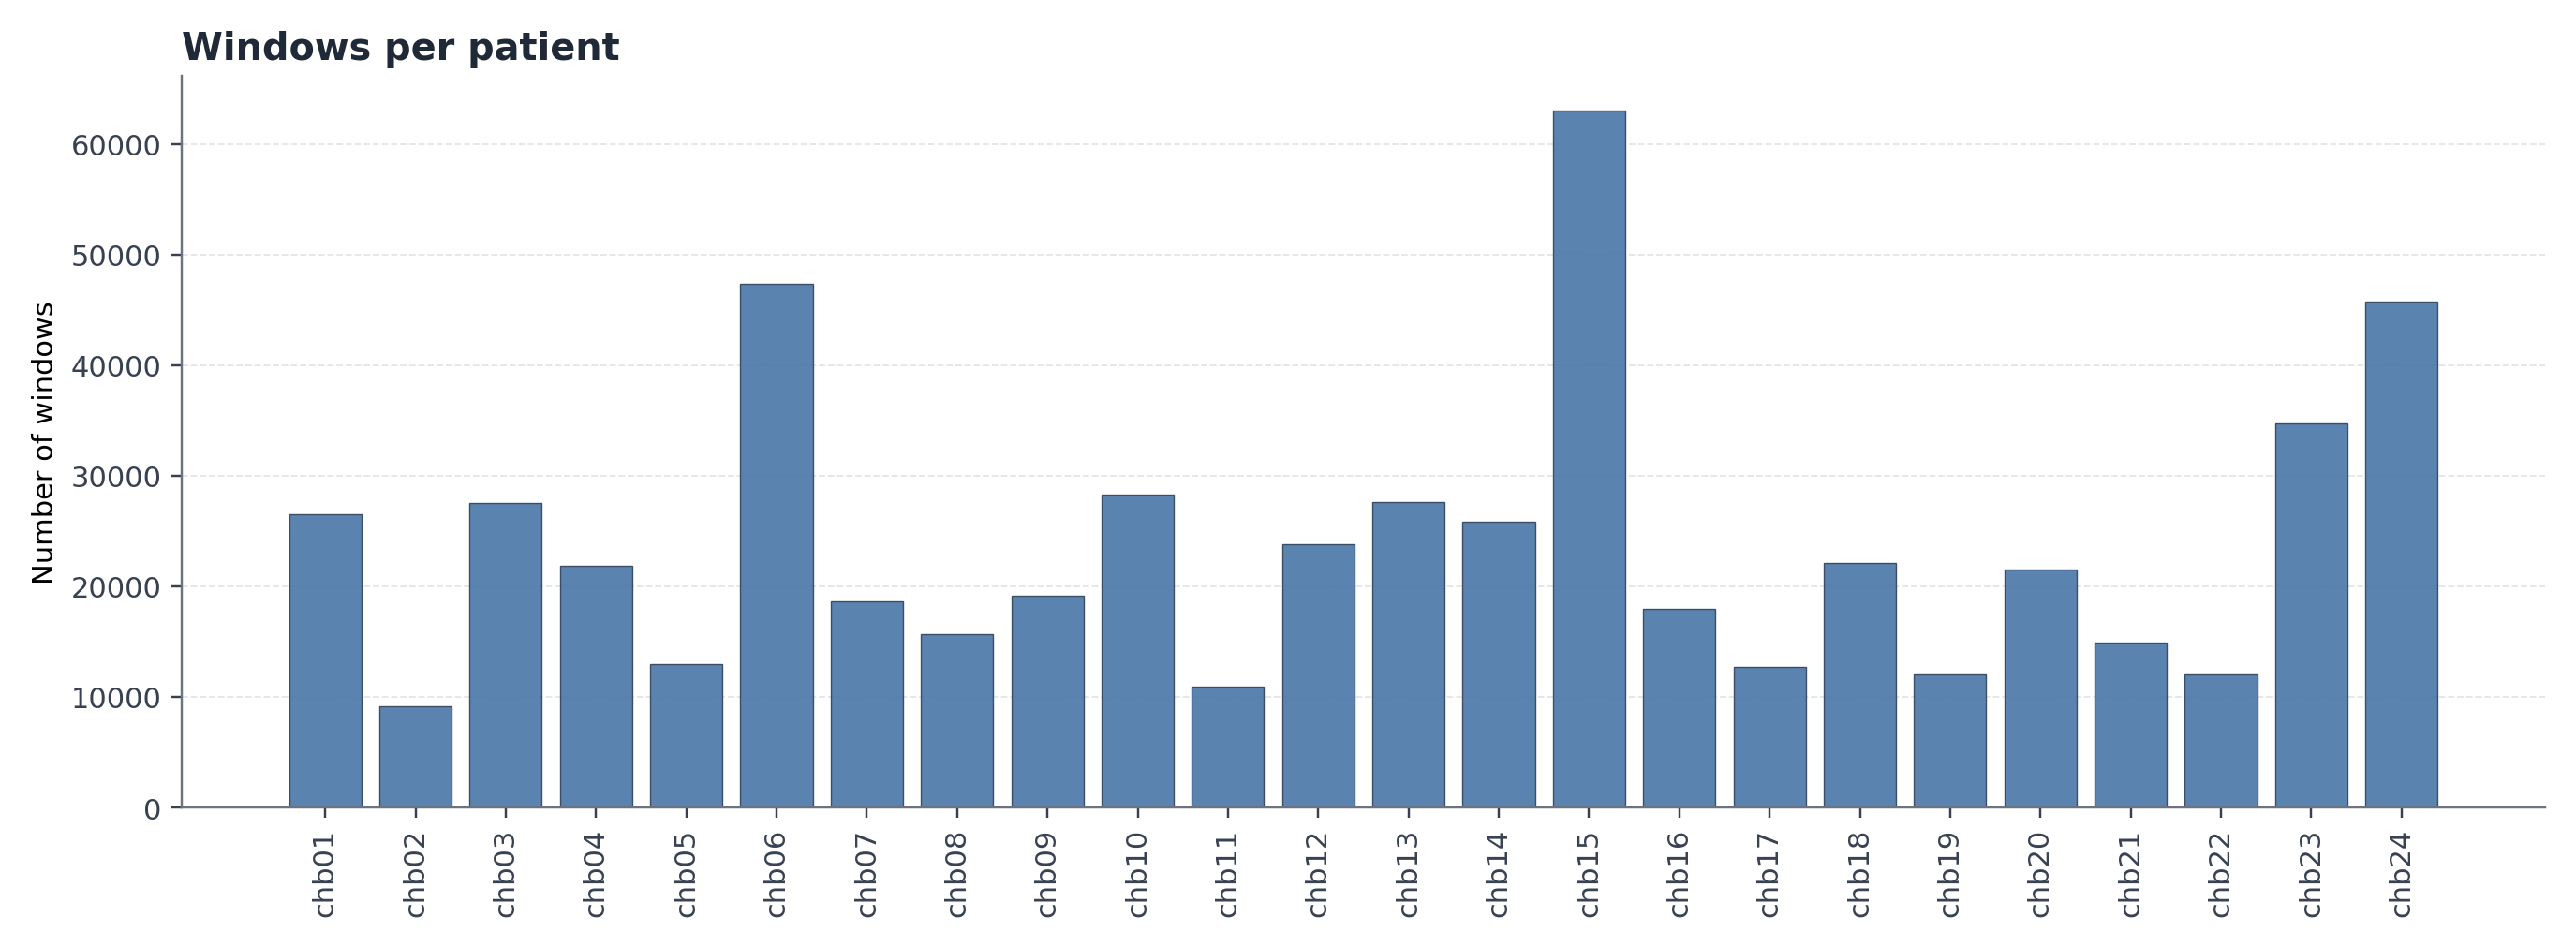

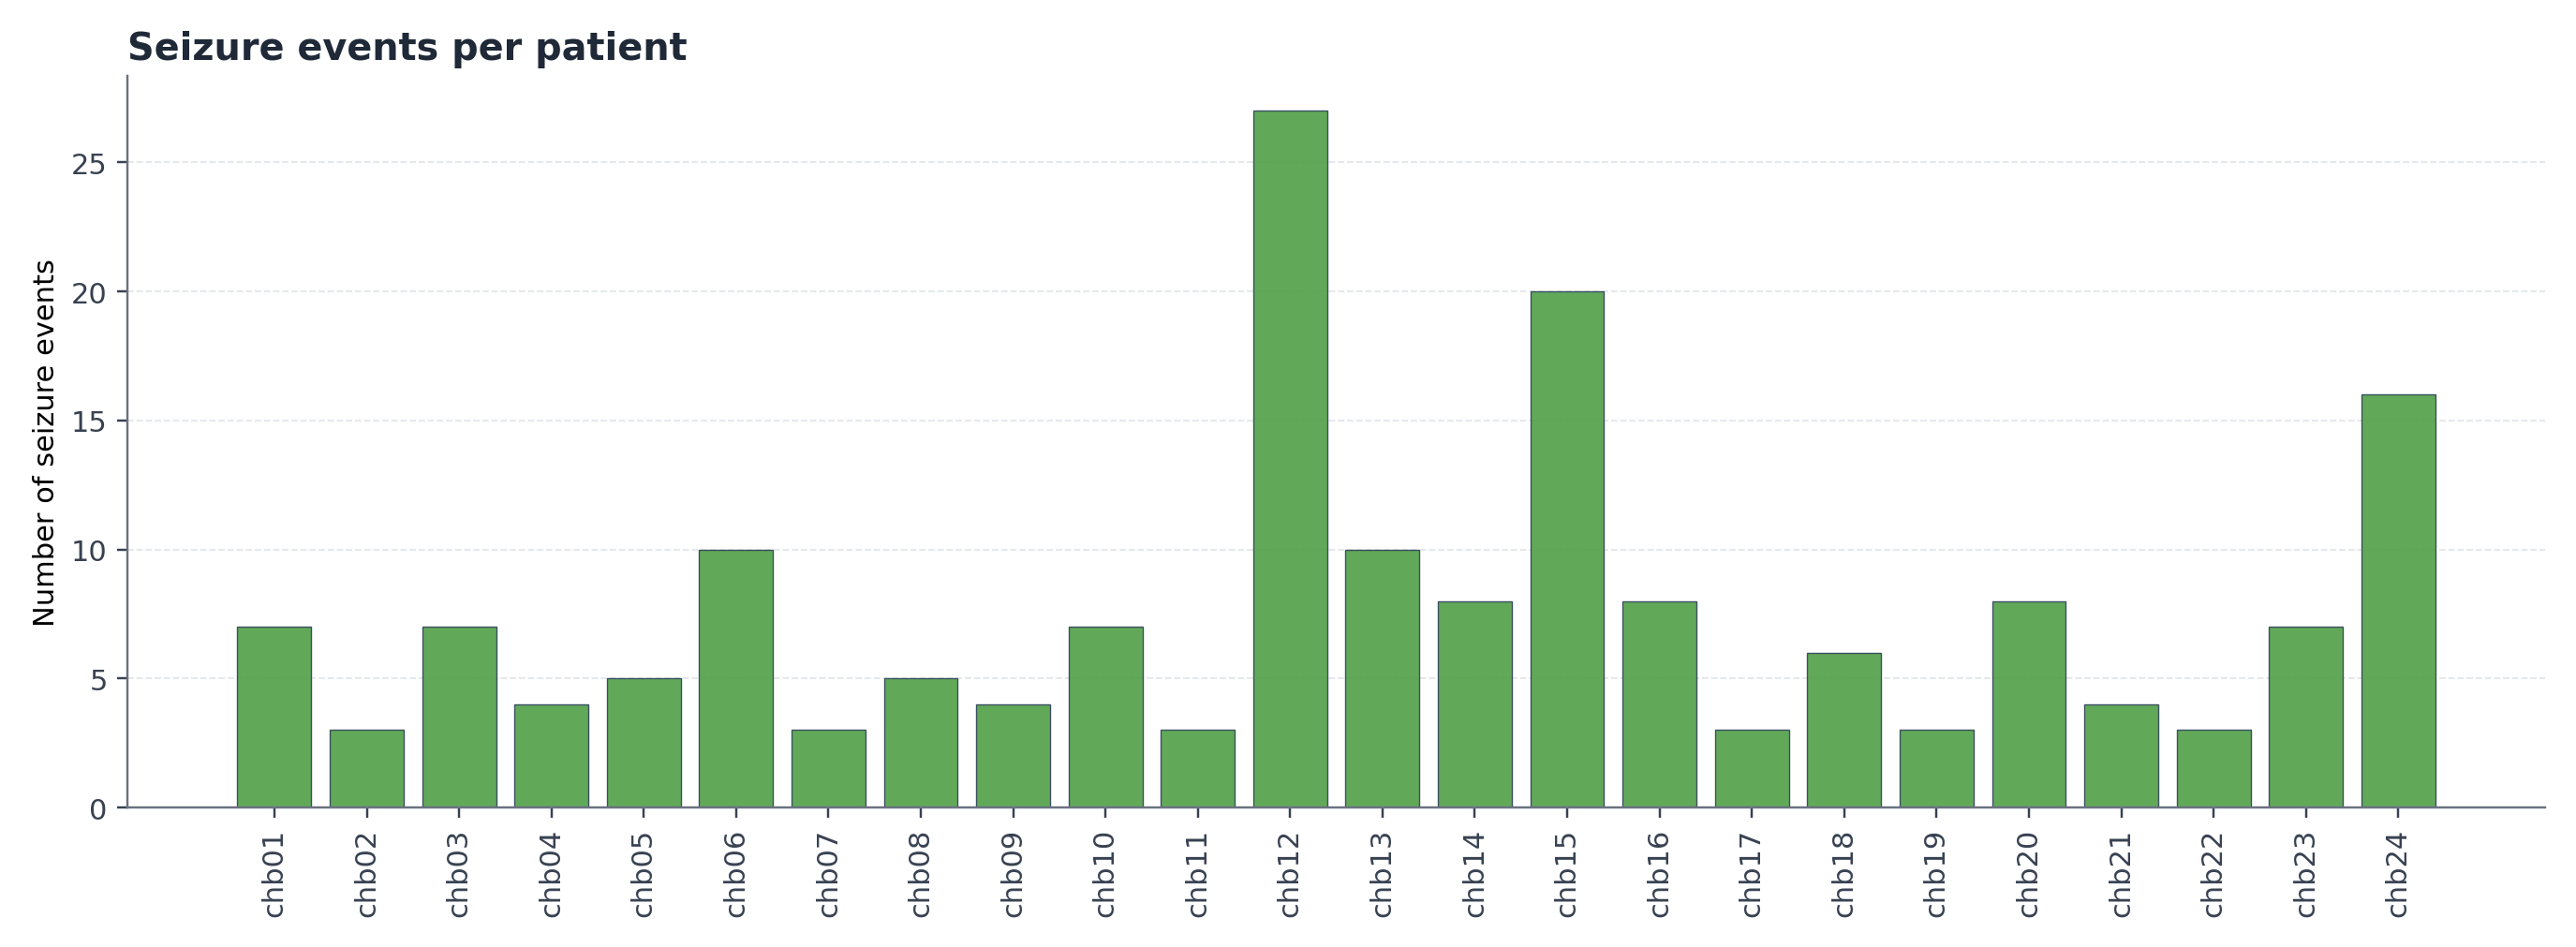

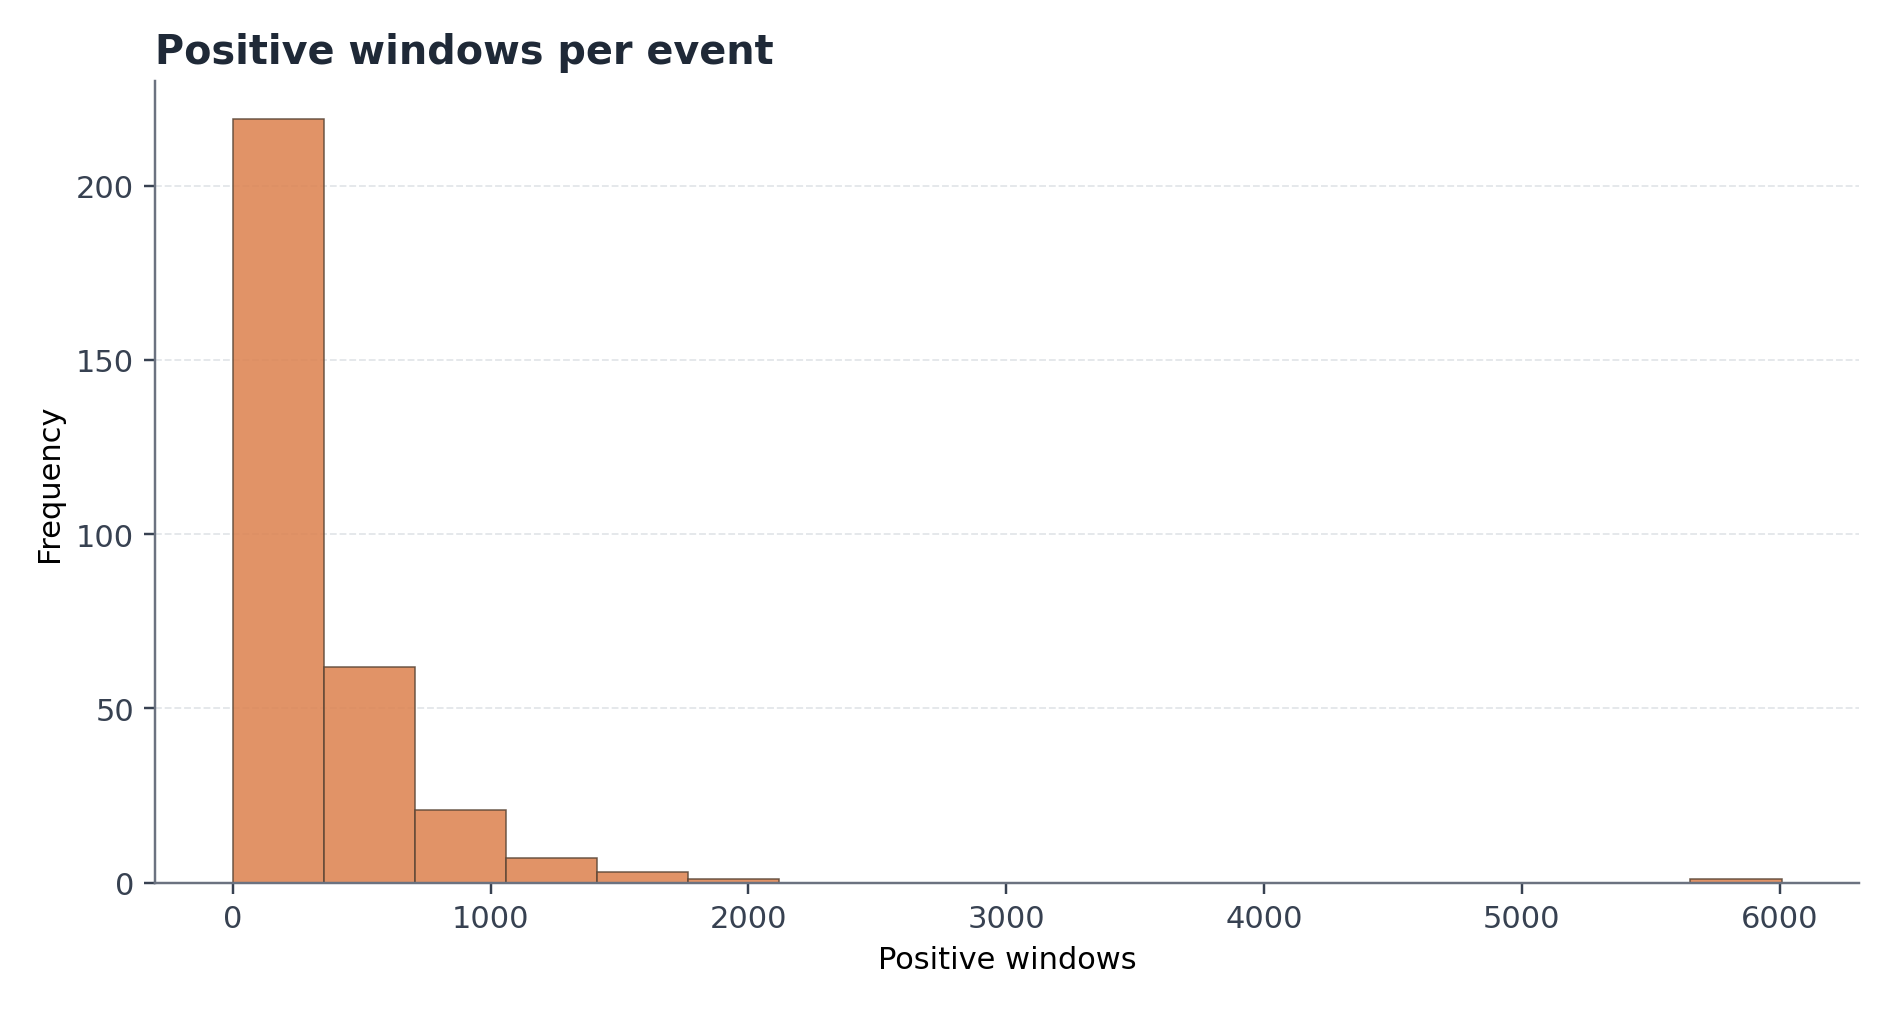

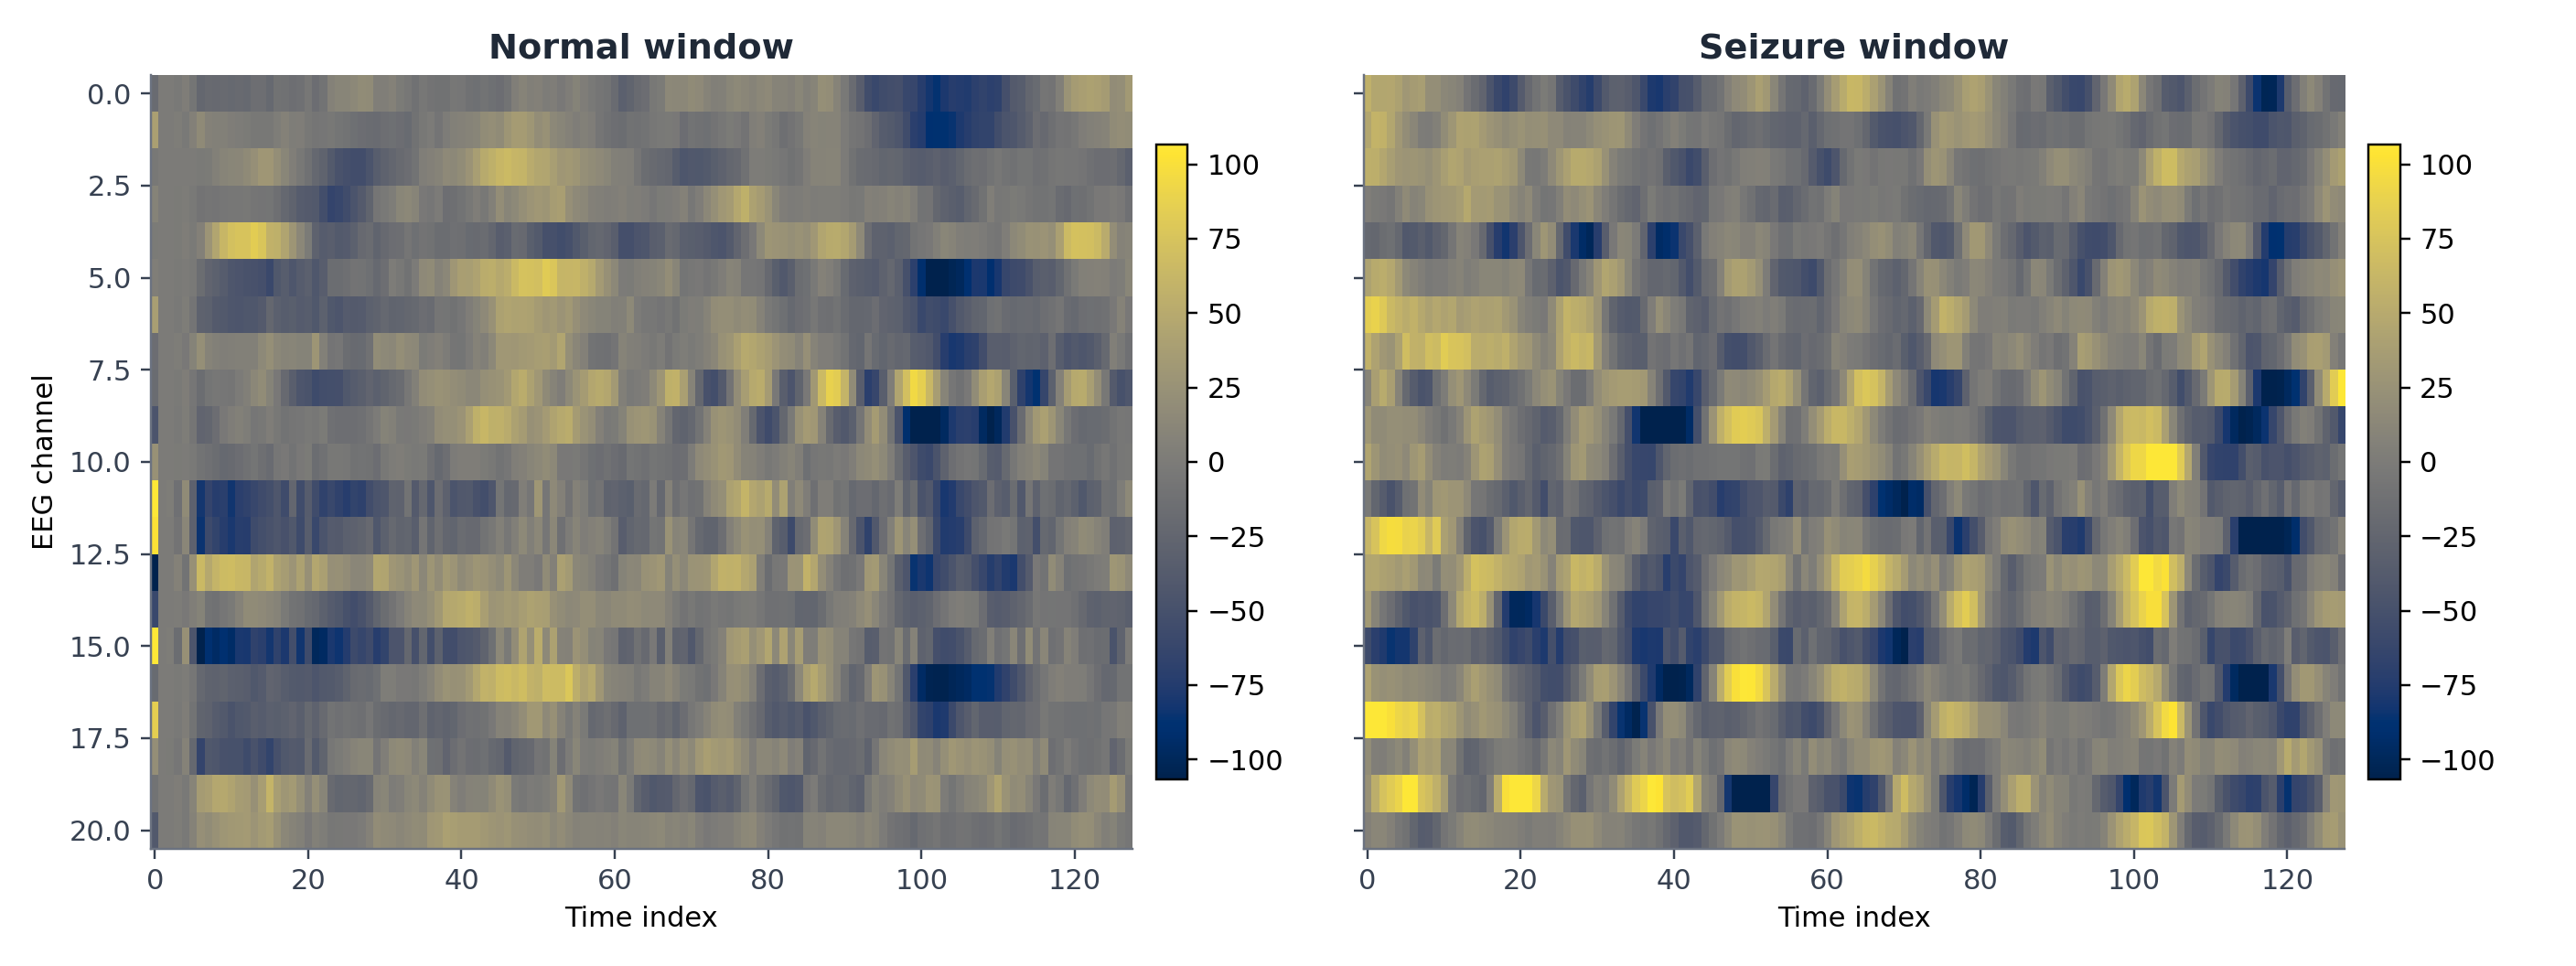

In [16]:
section_header('Fold 3 Artifact View', 'The plots are intentionally placed after protocol design so teammates can immediately connect them to the evaluation story.')
artifact_card('Audit folder', ROOT / 'fold2_data_audit', 'Contains the descriptive tables and figures used in the report.')
show_preview(ROOT / 'fold2_data_audit' / 'eda_summary.md')
show_preview(ROOT / 'fold2_data_audit' / 'patient_stats.csv')
show_preview(ROOT / 'fold2_data_audit' / 'class_ratio.csv')
show_preview(ROOT / 'fold2_data_audit' / 'event_stats.csv')
show_figure(ROOT / 'fold2_data_audit' / 'windows_per_patient.png', 'windows_per_patient', width=1100)
show_figure(ROOT / 'fold2_data_audit' / 'seizures_per_patient.png', 'seizures_per_patient', width=1100)
show_figure(ROOT / 'fold2_data_audit' / 'interval_length_distribution.png', 'interval_length_distribution', width=850)
show_figure(ROOT / 'fold2_data_audit' / 'sample_windows.png', 'sample_windows', width=1000)


### Fold 3 Static Tables

> Static fallback for the audit tables and summary text.

<div style="margin:14px 0 22px 0;padding:12px 14px;border:1px solid #e5e7eb;border-left:6px solid #4b5563;border-radius:10px;background:#fcfcfd;"><div style="font-weight:700;color:#1f2937;margin-bottom:10px;">EDA summary</div><pre style="margin:0;white-space:pre-wrap;word-break:break-word;font-size:13px;line-height:1.6;color:#374151;"># EDA Summary

- Total patients: `24`
- Total windows: `571905`
- Total seizure windows: `86672`
- Total normal windows: `485233`
- Total seizure events: `27` within-patient unique ids

## Key observations

- The dataset is strongly imbalanced toward normal windows.
- Event counts vary substantially across patients.
- Window-level validation should be interpreted as an upper bound because train and test can share patient/event context.</pre></div>

<div style="margin:14px 0 22px 0;padding:12px 14px;border:1px solid #e5e7eb;border-left:6px solid #4b5563;border-radius:10px;background:#fcfcfd;"><div style="font-weight:700;color:#1f2937;margin-bottom:6px;">Patient statistics</div><div style="color:#4b5563;margin-bottom:10px;">Showing full table: 24 rows x 6 columns.</div><div style="overflow-x:auto;"><table style="border-collapse:collapse;width:100%;font-size:13px;line-height:1.45;border:1px solid #d1d5db;background:white;"><thead><tr><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">patient_id</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">n_windows</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">n_pos_windows</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">n_neg_windows</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">n_files</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">n_events</th></tr></thead><tbody><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">26529</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3480</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">23049</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb02</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">9153</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1352</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7801</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">27524</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3160</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24364</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb04</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">21860</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2992</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">18868</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb05</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">12992</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4424</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8568</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb06</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">47370</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1144</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">46226</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb07</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">18591</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2576</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">16015</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb08</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">15700</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7312</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8388</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb09</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">19165</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2176</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">16989</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">28315</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3520</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24795</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb11</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10959</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6424</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4535</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">23810</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7696</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">16114</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">27</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">27583</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3440</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24143</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">25824</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1288</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24536</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">62984</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">15776</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">47208</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">20</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb16</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">17926</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">488</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">17438</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb17</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">12665</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2320</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10345</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb18</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">22073</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2488</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">19585</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb19</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">11988</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1864</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10124</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb20</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">21536</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2288</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">19248</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb21</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">14903</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1560</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">13343</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb22</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">12018</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1608</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10410</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb23</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">34736</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3336</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">31400</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">45701</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3960</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">41741</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">16</td></tr></tbody></table></div></div>

<div style="margin:14px 0 22px 0;padding:12px 14px;border:1px solid #e5e7eb;border-left:6px solid #4b5563;border-radius:10px;background:#fcfcfd;"><div style="font-weight:700;color:#1f2937;margin-bottom:6px;">Class ratio</div><div style="color:#4b5563;margin-bottom:10px;">Showing full table: 2 rows x 4 columns.</div><div style="overflow-x:auto;"><table style="border-collapse:collapse;width:100%;font-size:13px;line-height:1.45;border:1px solid #d1d5db;background:white;"><thead><tr><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">label</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">class_label</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">n_windows</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">ratio</th></tr></thead><tbody><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">normal</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">485233</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.8484503545169215</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">86672</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.1515496454830784</td></tr></tbody></table></div></div>

<div style="margin:14px 0 22px 0;padding:12px 14px;border:1px solid #e5e7eb;border-left:6px solid #4b5563;border-radius:10px;background:#fcfcfd;"><div style="font-weight:700;color:#1f2937;margin-bottom:6px;">Event statistics</div><div style="color:#4b5563;margin-bottom:10px;">Showing first 20 of 314 rows (6 columns).</div><div style="overflow-x:auto;"><table style="border-collapse:collapse;width:100%;font-size:13px;line-height:1.45;border:1px solid #d1d5db;background:white;"><thead><tr><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">patient_id</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">global_interval</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">n_windows</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">n_pos_windows</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">n_neg_windows</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">files</th></tr></thead><tbody><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3277</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">312</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2965</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">741</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">208</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">533</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1748</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">312</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1436</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2475</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">400</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2075</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2413</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">712</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1701</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2533</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">736</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1797</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1784</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">800</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">984</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">8</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2503</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2503</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">9</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1689</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1689</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">10</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1759</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1759</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">11</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">296</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">296</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">12</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3149</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3149</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">13</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1831</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1831</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">14</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">331</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">331</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb02</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3581</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">640</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2941</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb02</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1164</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">648</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">516</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb02</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">163</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">64</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">99</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb02</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">4</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">716</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">716</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb02</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">5</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3338</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3338</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">chb02</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">6</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">191</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">191</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td></tr></tbody></table></div></div>



## Fold 4: Input Pipeline

**Goal**
- Materialize float32 caches, save normalization stats, and prove the loaders can feed the CNN.

**What We Produce**
- `fold4_input_pipeline/<protocol>/<train_mode>/<outer_fold>/norm_stats.json`
- `loader_smoke_report.json`

**Human Takeaway**
- This fold bridges the raw EEG storage format and GPU-friendly training tensors.

In [17]:
cache_dir = ROOT / 'fold4_input_pipeline' / 'patient_cache'
artifact_card('Patient float32 cache directory', cache_dir, 'One cache per patient, reused by all folds.')
sample_norm = next(iter((ROOT / 'fold4_input_pipeline').glob('*/*/outer_fold_*/norm_stats.json')), None)
if sample_norm:
    show_preview(sample_norm)
else:
    display(Markdown('**No normalization stats found yet.**'))

,mean,std
0,"[1.379278302192688, -0.3208346962928772, -0.11...","[102.66647338867188, 109.11710357666016, 97.20..."


### Fold 4 Static Tables

> Static fallback for the input-pipeline normalization artifact.

<div style="margin:14px 0 22px 0;padding:12px 14px;border:1px solid #e5e7eb;border-left:6px solid #4b5563;border-radius:10px;background:#fcfcfd;"><div style="font-weight:700;color:#1f2937;margin-bottom:6px;">Sample normalization stats: fold4_input_pipeline/patient/balanced_50_50/outer_fold_000/norm_stats.json</div><pre style="margin:0;white-space:pre-wrap;word-break:break-word;font-size:13px;line-height:1.55;color:#374151;">{
  &quot;mean&quot;: [
    1.379278302192688,
    -0.3208346962928772,
    -0.11379815638065338,
    0.9989197254180908,
    2.3222036361694336,
    -0.015617147088050842,
    -0.4350561499595642,
    0.056599363684654236,
    2.60867977142334,
    0.6913919448852539,
    0.5107100009918213,
    0.017057210206985474,
    3.945204973220825,
    -0.23229725658893585,
    -0.9007535576820374,
    1.0381641387939453,
    0.36707252264022827,
    -0.19124343991279602,
    -0.4937899708747864,
    2.261183261871338,
    0.35183969140052795
  ],
  &quot;std&quot;: [
    102.66647338867188,
    109.11710357666016,
    97.20680236816406,
    97.3890151977539,
    106.65958404541016,
    114.19725036621094,
    84.2279281616211,
    91.21569061279297,
    109.22488403320312,
    104.82946014404297,
    81.37381744384766,
    100.25163269042969,
    104.57540130615234,
    87.68128204345703,
    80.32533264160156,
    90.55110168457031,
    99.35794067382812,
    67.62641906738281,
    103.72237396240234,
    123.09708404541016,
    67.86236572265625
  ]
}</pre></div>



## Fold 5: CNN Training

**Goal**
- Train the 1D CNN under each protocol and train sampling strategy.

**What We Produce**
- `best.pt`
- `train_log.csv`
- `learning_curve.png`
- `run_config.yaml`
- `status.json` in shard run directories

**Human Takeaway**
- This fold is where the experiment matrix actually becomes compute jobs.

,protocol,train_mode,shard_name,smoke,status,device,completed_folds,failed_folds,started_at,finished_at,test_modes,status_path
0,patient,balanced_50_50,shard_00_of_01,False,done,cuda,24,0,2026-03-19T21:30:29.363352+00:00,2026-03-19T21:48:22.732972+00:00,"balanced_50_50,unbalanced_20_80",/export/hhome/ricse03/Deep_Learning_Group 3/ho...
1,patient,unbalanced_20_80,shard_00_of_01,False,done,cuda,24,0,2026-03-19T22:01:45.904434+00:00,2026-03-19T22:27:30.187248+00:00,"balanced_50_50,unbalanced_20_80",/export/hhome/ricse03/Deep_Learning_Group 3/ho...
2,seizure,balanced_50_50,shard_00_of_03,False,done,cuda,61,0,2026-03-19T20:56:28.591218+00:00,2026-03-19T22:11:51.798774+00:00,"balanced_50_50,unbalanced_20_80",/export/hhome/ricse03/Deep_Learning_Group 3/ho...
3,seizure,balanced_50_50,shard_01_of_03,False,done,cuda,60,0,2026-03-19T20:56:28.365945+00:00,2026-03-19T22:06:08.718105+00:00,"balanced_50_50,unbalanced_20_80",/export/hhome/ricse03/Deep_Learning_Group 3/ho...
4,seizure,balanced_50_50,shard_02_of_03,False,done,cuda,60,0,2026-03-19T20:56:29.036513+00:00,2026-03-19T22:06:35.062733+00:00,"balanced_50_50,unbalanced_20_80",/export/hhome/ricse03/Deep_Learning_Group 3/ho...
5,seizure,unbalanced_20_80,shard_00_of_03,False,done,cuda,61,0,2026-03-19T20:56:28.483453+00:00,2026-03-19T22:43:51.642411+00:00,"balanced_50_50,unbalanced_20_80",/export/hhome/ricse03/Deep_Learning_Group 3/ho...
6,seizure,unbalanced_20_80,shard_01_of_03,False,done,cuda,60,0,2026-03-19T20:56:28.810037+00:00,2026-03-19T22:40:17.571460+00:00,"balanced_50_50,unbalanced_20_80",/export/hhome/ricse03/Deep_Learning_Group 3/ho...
7,seizure,unbalanced_20_80,shard_02_of_03,False,done,cuda,60,0,2026-03-19T20:56:28.699301+00:00,2026-03-19T22:43:12.120004+00:00,"balanced_50_50,unbalanced_20_80",/export/hhome/ricse03/Deep_Learning_Group 3/ho...
8,window,balanced_50_50,shard_00_of_01,False,done,cuda,15,0,2026-03-19T20:56:27.812847+00:00,2026-03-19T21:30:25.770272+00:00,"balanced_50_50,unbalanced_20_80",/export/hhome/ricse03/Deep_Learning_Group 3/ho...
9,window,unbalanced_20_80,shard_00_of_01,False,done,cuda,15,0,2026-03-19T20:56:28.923861+00:00,2026-03-19T22:01:42.450003+00:00,"balanced_50_50,unbalanced_20_80",/export/hhome/ricse03/Deep_Learning_Group 3/ho...


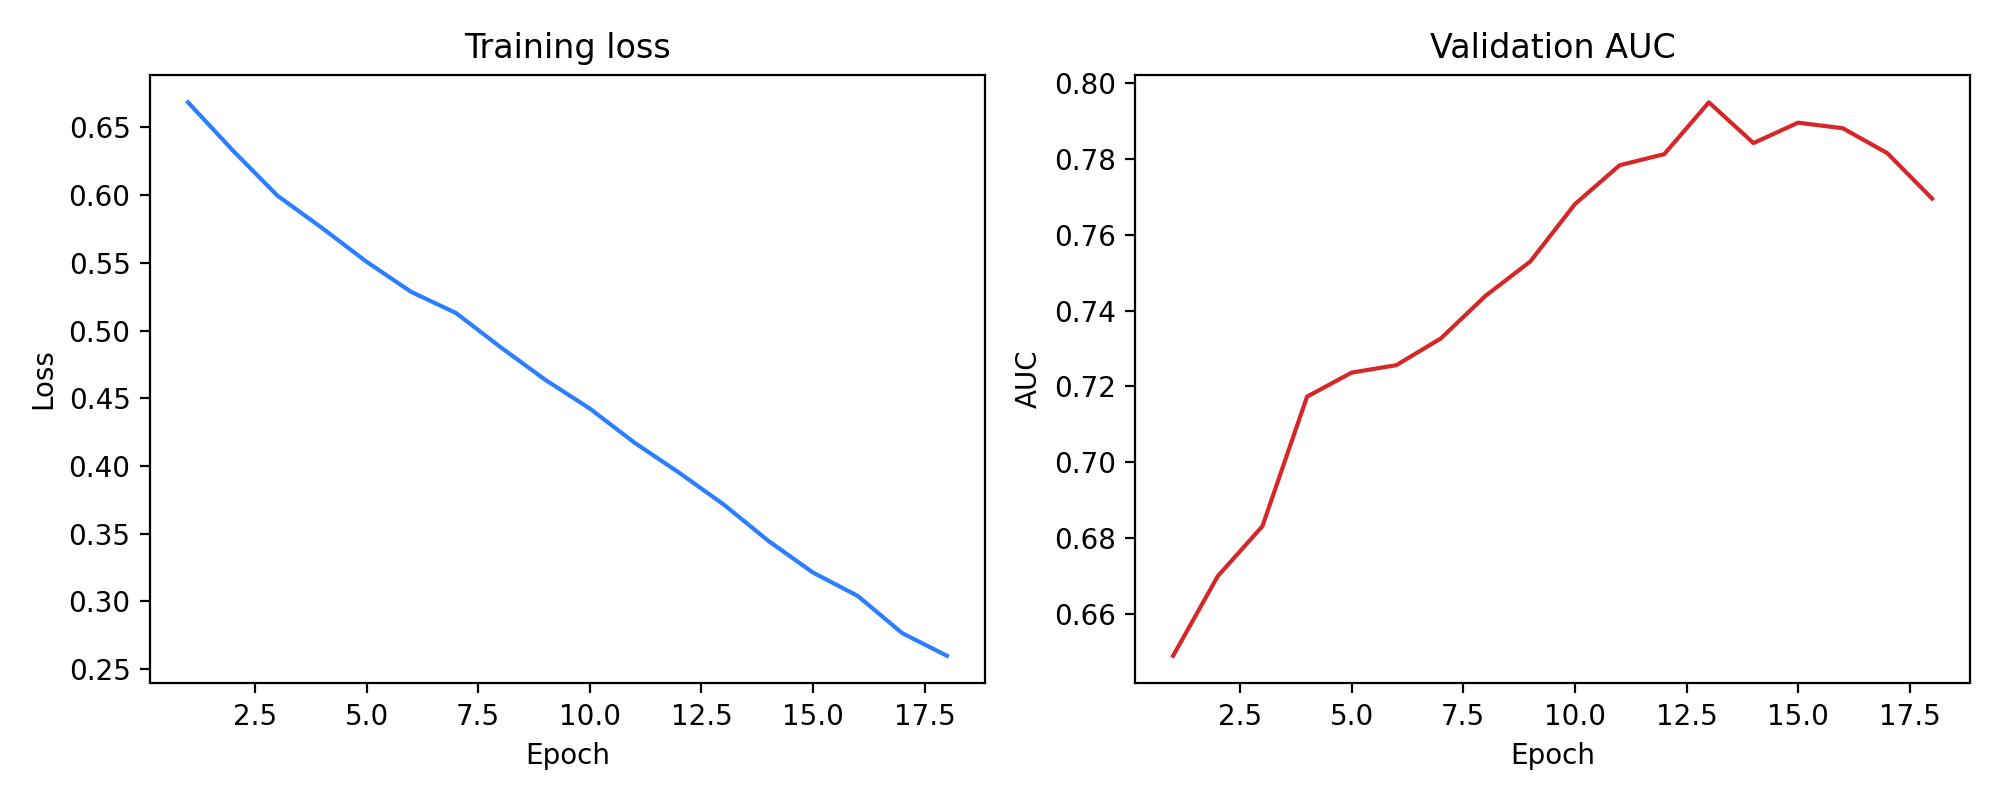

In [18]:
show_preview(ROOT / 'fold5_cnn_training' / 'run_status_summary.csv')
sample_curve = next(iter((ROOT / 'fold5_cnn_training').glob('*/*/outer_fold_*/learning_curve.png')), None)
if sample_curve:
    show_figure(sample_curve, 'sample_learning_curve', width=1000)
else:
    display(Markdown('**No learning curve found yet.**'))


### Fold 5 Static Tables

> Static fallback for the training status summary.

<div style="margin:14px 0 22px 0;padding:12px 14px;border:1px solid #e5e7eb;border-left:6px solid #4b5563;border-radius:10px;background:#fcfcfd;"><div style="font-weight:700;color:#1f2937;margin-bottom:6px;">Run status summary</div><div style="color:#4b5563;margin-bottom:10px;">Showing full table: 10 rows x 12 columns.</div><div style="overflow-x:auto;"><table style="border-collapse:collapse;width:100%;font-size:13px;line-height:1.45;border:1px solid #d1d5db;background:white;"><thead><tr><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">protocol</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">train_mode</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">shard_name</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">smoke</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">status</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">device</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">completed_folds</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">failed_folds</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">started_at</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">finished_at</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">test_modes</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">status_path</th></tr></thead><tbody><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">shard_00_of_01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">False</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">done</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">cuda</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T21:30:29.363352+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T21:48:22.732972+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50,unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/fold5_cnn_training/runs/patient/balanced_50_50/shard_00_of_01/status.json</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">shard_00_of_01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">False</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">done</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">cuda</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T22:01:45.904434+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T22:27:30.187248+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50,unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/fold5_cnn_training/runs/patient/unbalanced_20_80/shard_00_of_01/status.json</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">shard_00_of_03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">False</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">done</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">cuda</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">61</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T20:56:28.591218+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T22:11:51.798774+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50,unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/fold5_cnn_training/runs/seizure/balanced_50_50/shard_00_of_03/status.json</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">shard_01_of_03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">False</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">done</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">cuda</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">60</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T20:56:28.365945+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T22:06:08.718105+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50,unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/fold5_cnn_training/runs/seizure/balanced_50_50/shard_01_of_03/status.json</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">shard_02_of_03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">False</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">done</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">cuda</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">60</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T20:56:29.036513+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T22:06:35.062733+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50,unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/fold5_cnn_training/runs/seizure/balanced_50_50/shard_02_of_03/status.json</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">shard_00_of_03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">False</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">done</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">cuda</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">61</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T20:56:28.483453+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T22:43:51.642411+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50,unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/fold5_cnn_training/runs/seizure/unbalanced_20_80/shard_00_of_03/status.json</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">shard_01_of_03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">False</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">done</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">cuda</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">60</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T20:56:28.810037+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T22:40:17.571460+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50,unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/fold5_cnn_training/runs/seizure/unbalanced_20_80/shard_01_of_03/status.json</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">shard_02_of_03</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">False</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">done</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">cuda</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">60</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T20:56:28.699301+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T22:43:12.120004+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50,unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/fold5_cnn_training/runs/seizure/unbalanced_20_80/shard_02_of_03/status.json</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">shard_00_of_01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">False</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">done</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">cuda</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T20:56:27.812847+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T21:30:25.770272+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50,unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/fold5_cnn_training/runs/window/balanced_50_50/shard_00_of_01/status.json</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">shard_00_of_01</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">False</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">done</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">cuda</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T20:56:28.923861+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2026-03-19T22:01:42.450003+00:00</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50,unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/fold5_cnn_training/runs/window/unbalanced_20_80/shard_00_of_01/status.json</td></tr></tbody></table></div></div>



## Research Visualizations

**Goal**
- Make channel fusion and single-case interpretability visually explicit in a report-friendly, scientific style.

**What We Load**
- One representative patient-holdout checkpoint and its test predictions.
- `fold7_results_and_reporting/research_visuals/*`

**What We Produce**
- `input_heatmap_pair.png`
- `channel_fusion_architecture.png`
- `first_layer_channel_fusion_weights.png`
- `saliency_case_patient_fold0.png`
- `research_visuals_manifest.json`
- `research_visuals_captions_zh.md`

**Human Takeaway**
- The CNN really does fuse all 21 EEG channels jointly, and we now have both global evidence (first-layer weights) and local evidence (saliency on a seizure case).

In [19]:
viz_dir = ROOT / 'fold7_results_and_reporting' / 'research_visuals'
artifact_card('Research visualization folder', viz_dir, 'Scientific-style figures for channel fusion and interpretability.')
show_preview(viz_dir / 'research_visuals_notes.md')
show_preview(viz_dir / 'research_visuals_manifest.json')
display(Markdown('**The static figure gallery with bilingual descriptions is shown in the next section to avoid duplicate renders.**'))


# Research-style Visualizations

## 1. Input Heatmap Pair
- Compares a representative non-seizure window and a representative seizure window from the same patient-holdout test fold.
- Shows the raw 21-channel by 128-sample matrix that enters the CNN.

## 2. Channel Fusion Architecture
- Explains that the baseline is a single-window classifier with input-level channel fusion.
- The first Conv1d layer already mixes all 21 EEG channels.

## 3. First-layer Weight Heatmap
- Summarizes how strongly each first-layer filter uses each EEG channel.
- Useful to justify that channel fusion is actually learned, not only claimed.

## 4. Saliency Figure
- Shows which channels and time regions contributed most to a seizure decision for one representative true-positive test example.

## Reference Slice
- Protocol: `patient`
- Train mode: `balanced_50_50`
- Test mode: `balanced_50_50`
- Outer fold: `000`
- Checkpoint: `/export/hhome/ricse03/Deep_Learning_Group 3/homework_wenqi/fold5_cnn_training/patient/balanced_50_50/outer_fold_000/best.pt`


,checkpoint_path,prediction_path,reference_outer_fold_id,reference_protocol,reference_test_mode,reference_train_mode,artifacts.captions_zh,artifacts.channel_fusion_architecture,artifacts.first_layer_channel_fusion_weights,artifacts.input_heatmap_pair,artifacts.notes,artifacts.saliency_case,representative_normal_case.filename,representative_normal_case.global_interval,representative_normal_case.patient_id,representative_normal_case.row_id,representative_normal_case.y_score,representative_seizure_case.filename,representative_seizure_case.global_interval,representative_seizure_case.patient_id,representative_seizure_case.row_id,representative_seizure_case.y_score
0,/export/hhome/ricse03/Deep_Learning_Group 3/ho...,/export/hhome/ricse03/Deep_Learning_Group 3/ho...,0,patient,balanced_50_50,balanced_50_50,/export/hhome/ricse03/Deep_Learning_Group 3/ho...,/export/hhome/ricse03/Deep_Learning_Group 3/ho...,/export/hhome/ricse03/Deep_Learning_Group 3/ho...,/export/hhome/ricse03/Deep_Learning_Group 3/ho...,/export/hhome/ricse03/Deep_Learning_Group 3/ho...,/export/hhome/ricse03/Deep_Learning_Group 3/ho...,chb01_15.edf,5,chb01,8739,0.314296,chb01_16.edf,4,chb01,14852,0.913147


**The static figure gallery with bilingual descriptions is shown in the next section to avoid duplicate renders.**

### Embedded Figure Gallery

> Static inline figures for quick viewing. These render when the notebook is opened, even before rerunning the visualization cell.

<div style="margin: 22px 0 28px 0;">
  <div style="font-weight: 700; margin-bottom: 8px; font-size: 18px; color: #1f2937;">图 6. 单窗口 EEG 输入热力图对比</div>
  <img src="fold7_results_and_reporting/research_visuals/input_heatmap_pair.png" style="width: 100%; max-width: 1200px; border: 1px solid #ddd; border-radius: 8px; display: block;" />
  <div style="margin-top: 10px; padding: 12px 14px; border: 1px solid #ddd4c5; border-left: 6px solid #8c5a3c; border-radius: 10px; background: #fffdf8; line-height: 1.68; color: #374151;">
    <div style="font-weight: 700; color: #1f2937; margin-bottom: 6px;">中文描述与分析</div>
    <div>描述：该图对比了一个代表性的非发作窗口和一个代表性的发作窗口。分析：它直观说明了模型的输入单位就是单个 EEG 窗口，这与 challenge 的 static baseline 完全一致。结合 patient / seizure / window 三种 protocol，这张图提醒我们：切分方式变的是泛化难度，不是输入定义本身。</div>
    <div style="font-weight: 700; color: #1f2937; margin: 12px 0 6px 0;">English Description and Analysis</div>
    <div>Description: This figure compares one representative non-seizure window with one representative seizure window. Analysis: It makes the model input explicit and aligns with the challenge's static single-window baseline. Across the three protocols, the input definition stays the same while the generalization difficulty changes.</div>
  </div>
</div>

<div style="margin: 22px 0 28px 0;">
  <div style="font-weight: 700; margin-bottom: 8px; font-size: 18px; color: #1f2937;">图 7. Channel Fusion CNN 基线结构示意图</div>
  <img src="fold7_results_and_reporting/research_visuals/channel_fusion_architecture.png" style="width: 100%; max-width: 1300px; border: 1px solid #ddd; border-radius: 8px; display: block;" />
  <div style="margin-top: 10px; padding: 12px 14px; border: 1px solid #ddd4c5; border-left: 6px solid #8c5a3c; border-radius: 10px; background: #fffdf8; line-height: 1.68; color: #374151;">
    <div style="font-weight: 700; color: #1f2937; margin-bottom: 6px;">中文描述与分析</div>
    <div>描述：该图概括了当前实现的 CNN baseline，从多通道输入到卷积块再到二分类输出。分析：第一层 Conv1d 直接以 21 个 EEG 通道作为输入，因此这里实现的是 input-level channel fusion。这与 challenge 中的 channel fusion baseline 对齐，同时也明确表明：当前版本还没有引入 temporal LSTM 分支。</div>
    <div style="font-weight: 700; color: #1f2937; margin: 12px 0 6px 0;">English Description and Analysis</div>
    <div>Description: This diagram summarizes the implemented CNN baseline from multichannel input to binary output. Analysis: Because the first Conv1d layer directly consumes all 21 EEG channels, the model already performs input-level channel fusion. This matches the challenge baseline and also clarifies that the temporal LSTM branch is not part of the current V1 implementation.</div>
  </div>
</div>

<div style="margin: 22px 0 28px 0;">
  <div style="font-weight: 700; margin-bottom: 8px; font-size: 18px; color: #1f2937;">图 8. 第一层卷积核的通道融合权重热图</div>
  <img src="fold7_results_and_reporting/research_visuals/first_layer_channel_fusion_weights.png" style="width: 100%; max-width: 1300px; border: 1px solid #ddd; border-radius: 8px; display: block;" />
  <div style="margin-top: 10px; padding: 12px 14px; border: 1px solid #ddd4c5; border-left: 6px solid #8c5a3c; border-radius: 10px; background: #fffdf8; line-height: 1.68; color: #374151;">
    <div style="font-weight: 700; color: #1f2937; margin-bottom: 6px;">中文描述与分析</div>
    <div>描述：热图展示第一层卷积核在不同 EEG 通道上的平均权重强度，右侧给出通道重要性排序。分析：不同卷积核对不同通道的依赖并不相同，这说明模型并不是机械地平均所有通道，而是在学习跨通道的差异化组合。这为“已经做了 channel fusion”提供了全局层面的结构证据。</div>
    <div style="font-weight: 700; color: #1f2937; margin: 12px 0 6px 0;">English Description and Analysis</div>
    <div>Description: The heatmap summarizes how strongly the first convolutional layer uses each EEG channel, and the side plot ranks channels by average importance. Analysis: The filters do not treat all channels equally, which suggests that the model is learning structured cross-channel combinations rather than a trivial uniform average. This provides global evidence that channel fusion is actually happening.</div>
  </div>
</div>

<div style="margin: 22px 0 28px 0;">
  <div style="font-weight: 700; margin-bottom: 8px; font-size: 18px; color: #1f2937;">图 9. 代表性发作样本的 Saliency 可解释性结果</div>
  <img src="fold7_results_and_reporting/research_visuals/saliency_case_patient_fold0.png" style="width: 100%; max-width: 1300px; border: 1px solid #ddd; border-radius: 8px; display: block;" />
  <div style="margin-top: 10px; padding: 12px 14px; border: 1px solid #ddd4c5; border-left: 6px solid #8c5a3c; border-radius: 10px; background: #fffdf8; line-height: 1.68; color: #374151;">
    <div style="font-weight: 700; color: #1f2937; margin-bottom: 6px;">中文描述与分析</div>
    <div>描述：上方为原始发作窗口，下方为对应的梯度显著性图，右侧给出该样本最重要的通道。分析：模型的关注并不是均匀分布在全部时间点和通道上，而是集中在少数高信息区域。这说明当前 CNN 在局部判别时具有一定可解释性，但也应强调它提供的是模型证据，不等同于临床因果解释。</div>
    <div style="font-weight: 700; color: #1f2937; margin: 12px 0 6px 0;">English Description and Analysis</div>
    <div>Description: The upper panel shows the raw seizure window, the lower panel shows the gradient-based saliency map, and the side bar chart ranks the most salient channels for this case. Analysis: The model focuses on specific channels and time segments rather than distributing attention uniformly. This gives local interpretability evidence, although it should still be interpreted as model evidence rather than a direct clinical causal explanation.</div>
  </div>
</div>



## Fold 6: Evaluation

**Goal**
- Produce predictions, metrics, confusion matrices, ROC, and PR curves for every test sampling mode.

**What We Produce**
- `predictions.parquet`
- `metrics.json`
- `confusion_matrix.csv`
- `roc_curve.csv`
- `pr_curve.csv`

**Human Takeaway**
- This is the fold where the 12-grid experiment becomes measurable.

In [20]:
sample_metrics = next(iter((ROOT / 'fold6_evaluation').glob('*/*/outer_fold_*/*/metrics.json')), None)
if sample_metrics:
    show_preview(sample_metrics)
    sample_confusion = sample_metrics.parent / 'confusion_matrix.csv'
    show_preview(sample_confusion)
else:
    display(Markdown('**No evaluation metrics found yet.**'))

,accuracy,f1,fn,fp,n_rows,n_test_rows,n_train_rows,n_val_rows,outer_fold_id,precision,protocol,recall,roc_auc,specificity,test_group_id,test_mode,threshold,tn,tp,train_mode
0,0.829454,0.853764,15,1172,6960,6960,159520,68906,0,0.74725,patient,0.99569,0.985185,0.663218,chb01,balanced_50_50,0.423677,2308,3465,balanced_50_50


,actual,predicted,count
0,0,0,2308
1,0,1,1172
2,1,0,15
3,1,1,3465


### Fold 6 Static Tables

> Static fallback for a representative evaluation output.

<div style="margin:14px 0 22px 0;padding:12px 14px;border:1px solid #e5e7eb;border-left:6px solid #4b5563;border-radius:10px;background:#fcfcfd;"><div style="font-weight:700;color:#1f2937;margin-bottom:6px;">Sample metrics: fold6_evaluation/patient/balanced_50_50/outer_fold_000/balanced_50_50/metrics.json</div><pre style="margin:0;white-space:pre-wrap;word-break:break-word;font-size:13px;line-height:1.55;color:#374151;">{
  &quot;accuracy&quot;: 0.8294540229885058,
  &quot;f1&quot;: 0.8537637058026366,
  &quot;fn&quot;: 15,
  &quot;fp&quot;: 1172,
  &quot;n_rows&quot;: 6960,
  &quot;n_test_rows&quot;: 6960,
  &quot;n_train_rows&quot;: 159520,
  &quot;n_val_rows&quot;: 68906,
  &quot;outer_fold_id&quot;: 0,
  &quot;precision&quot;: 0.7472503773991805,
  &quot;protocol&quot;: &quot;patient&quot;,
  &quot;recall&quot;: 0.9956896551724138,
  &quot;roc_auc&quot;: 0.9851847998414586,
  &quot;specificity&quot;: 0.6632183908045977,
  &quot;test_group_id&quot;: &quot;chb01&quot;,
  &quot;test_mode&quot;: &quot;balanced_50_50&quot;,
  &quot;threshold&quot;: 0.42367658019065857,
  &quot;tn&quot;: 2308,
  &quot;tp&quot;: 3465,
  &quot;train_mode&quot;: &quot;balanced_50_50&quot;
}</pre></div>

<div style="margin:14px 0 22px 0;padding:12px 14px;border:1px solid #e5e7eb;border-left:6px solid #4b5563;border-radius:10px;background:#fcfcfd;"><div style="font-weight:700;color:#1f2937;margin-bottom:6px;">Sample confusion matrix: fold6_evaluation/patient/balanced_50_50/outer_fold_000/balanced_50_50/confusion_matrix.csv</div><div style="color:#4b5563;margin-bottom:10px;">Showing full table: 4 rows x 3 columns.</div><div style="overflow-x:auto;"><table style="border-collapse:collapse;width:100%;font-size:13px;line-height:1.45;border:1px solid #d1d5db;background:white;"><thead><tr><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">actual</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">predicted</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">count</th></tr></thead><tbody><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2308</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1172</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">15</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">1</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">3465</td></tr></tbody></table></div></div>



## Fold 7: Results and Reporting

**Goal**
- Aggregate every completed run into the main comparison tables and figures used in the report.

**What We Produce**
- `main_results.csv`
- `main_table.tex`
- `summary_figures/*.png`
- `research_visuals/*.png`
- `applications_discussion.md`
- `report_ready_notes.md`

**Human Takeaway**
- This fold is the shortest path from experiment outputs to defense slides and final writing.

,protocol,train_mode,test_mode,n_folds,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,specificity_mean,specificity_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,n_rows_mean
0,patient,balanced_50_50,balanced_50_50,24,0.729422,0.147420,0.819786,0.188123,0.631185,0.349375,0.827659,0.213175,0.642025,0.284133,0.853687,0.181300,7065.250000
1,patient,balanced_50_50,unbalanced_20_80,24,0.789669,0.144839,0.624245,0.280833,0.630717,0.348576,0.829407,0.213125,0.531197,0.251272,0.853905,0.180135,13800.416667
2,patient,unbalanced_20_80,balanced_50_50,24,0.744421,0.158432,0.832689,0.187592,0.648727,0.346988,0.840115,0.209454,0.661110,0.293145,0.853626,0.186745,7065.250000
3,patient,unbalanced_20_80,unbalanced_20_80,24,0.802646,0.150739,0.645989,0.271185,0.648765,0.346280,0.841116,0.209712,0.556097,0.265792,0.854072,0.185168,13800.416667
4,seizure,balanced_50_50,balanced_50_50,181,0.770542,0.132238,0.906368,0.188767,0.574999,0.274494,0.966085,0.048360,0.670745,0.257491,0.902744,0.126295,907.270718
5,seizure,balanced_50_50,unbalanced_20_80,181,0.887543,0.057196,0.798195,0.231394,0.574871,0.274739,0.965711,0.047013,0.634239,0.246965,0.902811,0.124927,2143.729282
6,seizure,unbalanced_20_80,balanced_50_50,181,0.783981,0.131380,0.920777,0.167940,0.596377,0.269728,0.971584,0.039160,0.692093,0.253988,0.908205,0.126618,907.270718
7,seizure,unbalanced_20_80,unbalanced_20_80,181,0.896729,0.054625,0.826227,0.215497,0.596578,0.270012,0.971766,0.038334,0.660709,0.244389,0.908443,0.125442,2143.729282
8,window,balanced_50_50,balanced_50_50,15,0.928806,0.002775,0.980257,0.002451,0.875254,0.006488,0.982359,0.002314,0.924767,0.003208,0.987509,0.001206,11556.266667
9,window,balanced_50_50,unbalanced_20_80,15,0.961053,0.001488,0.926010,0.006265,0.875254,0.006488,0.982503,0.001657,0.899889,0.003850,0.987583,0.001057,28890.666667


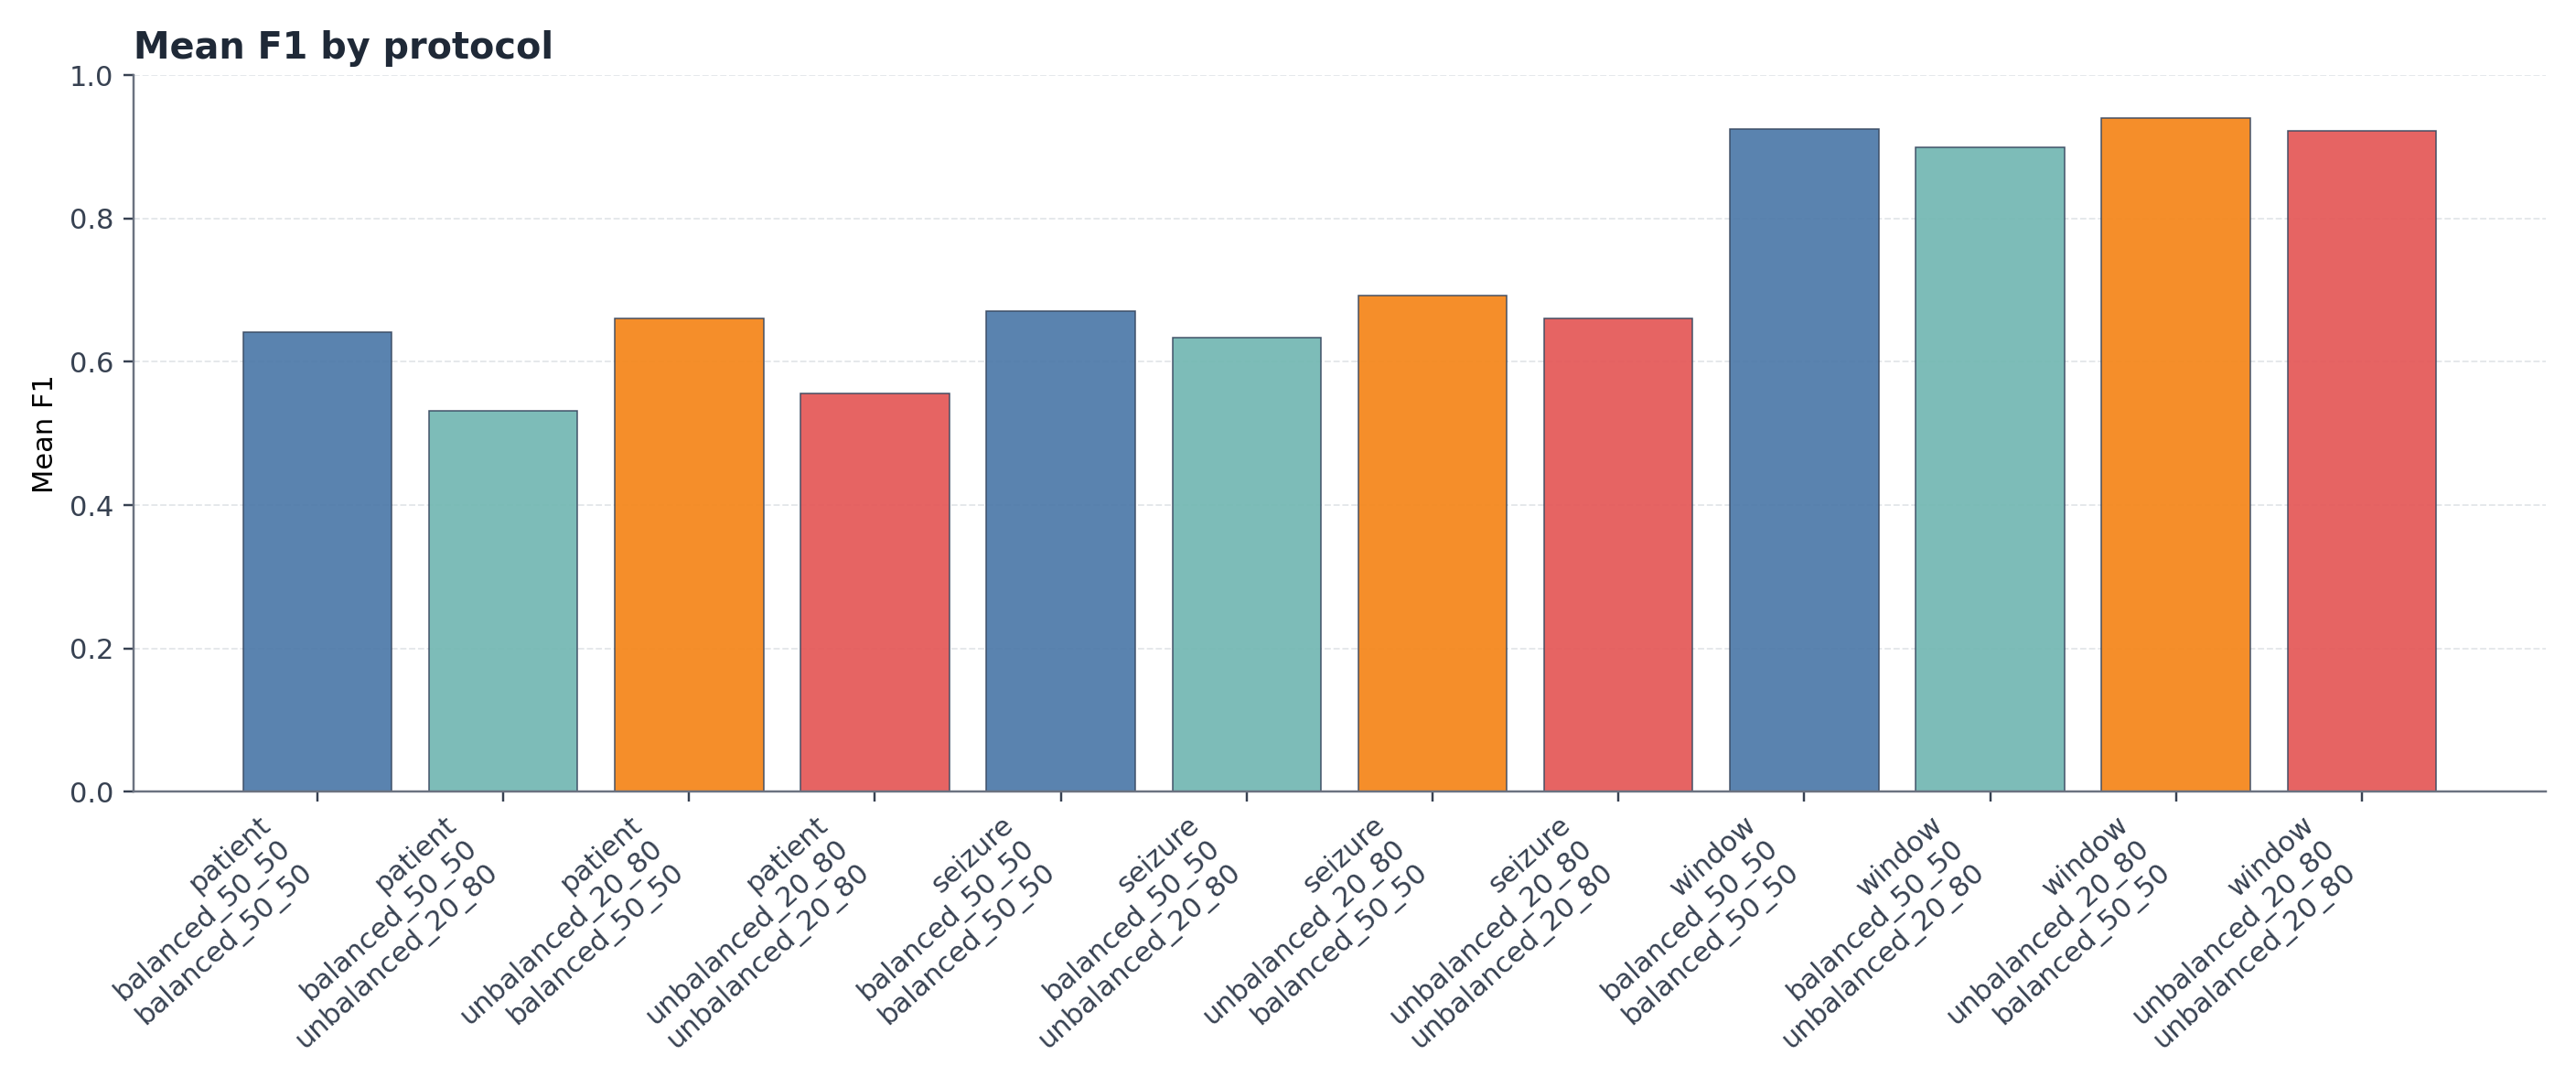

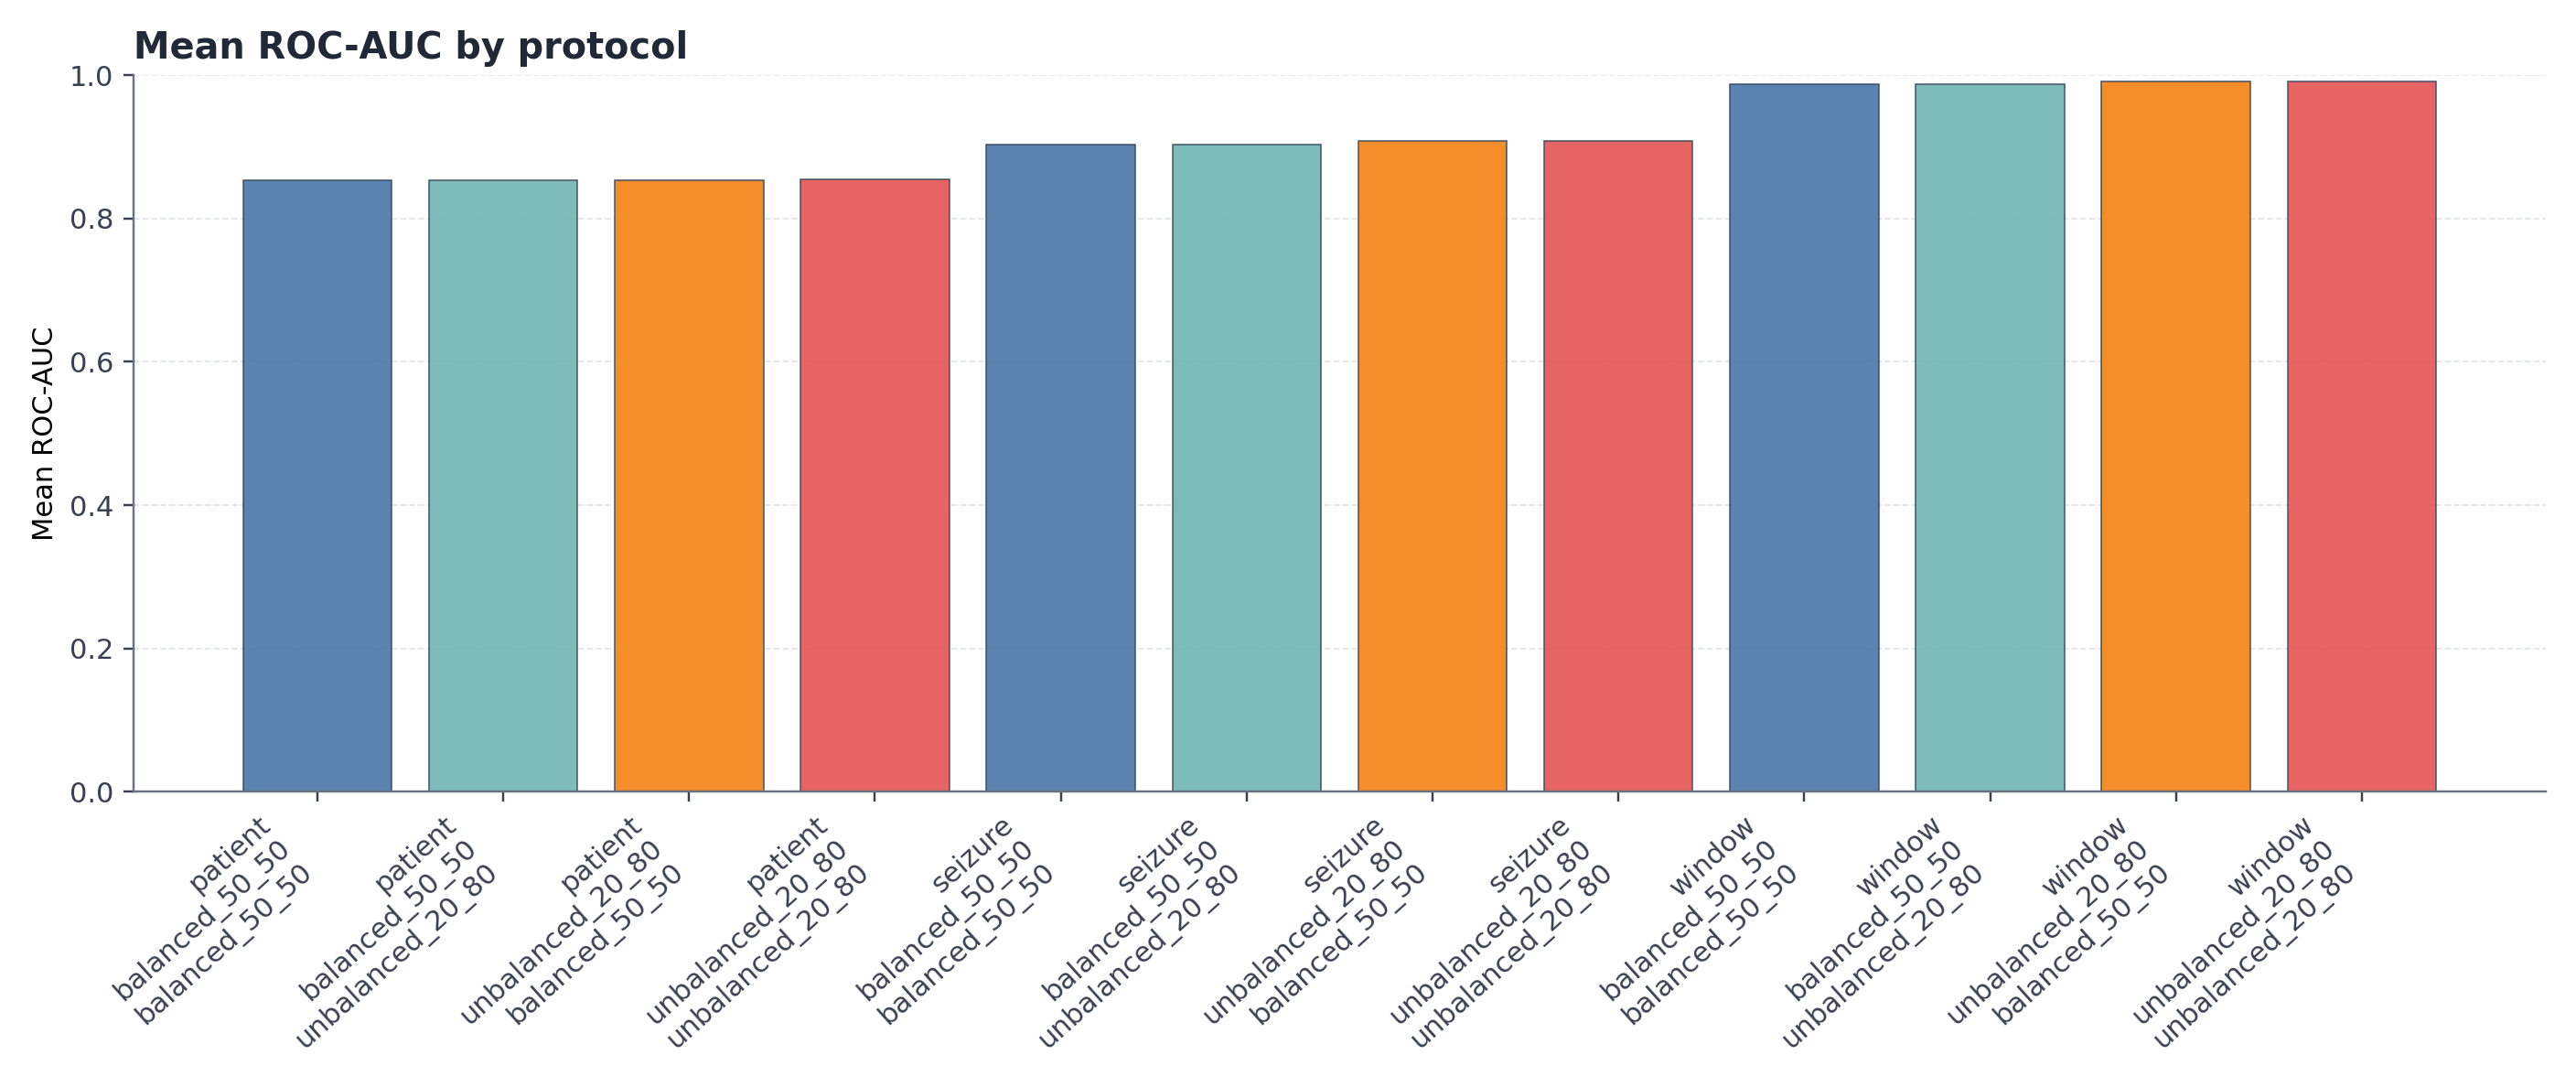

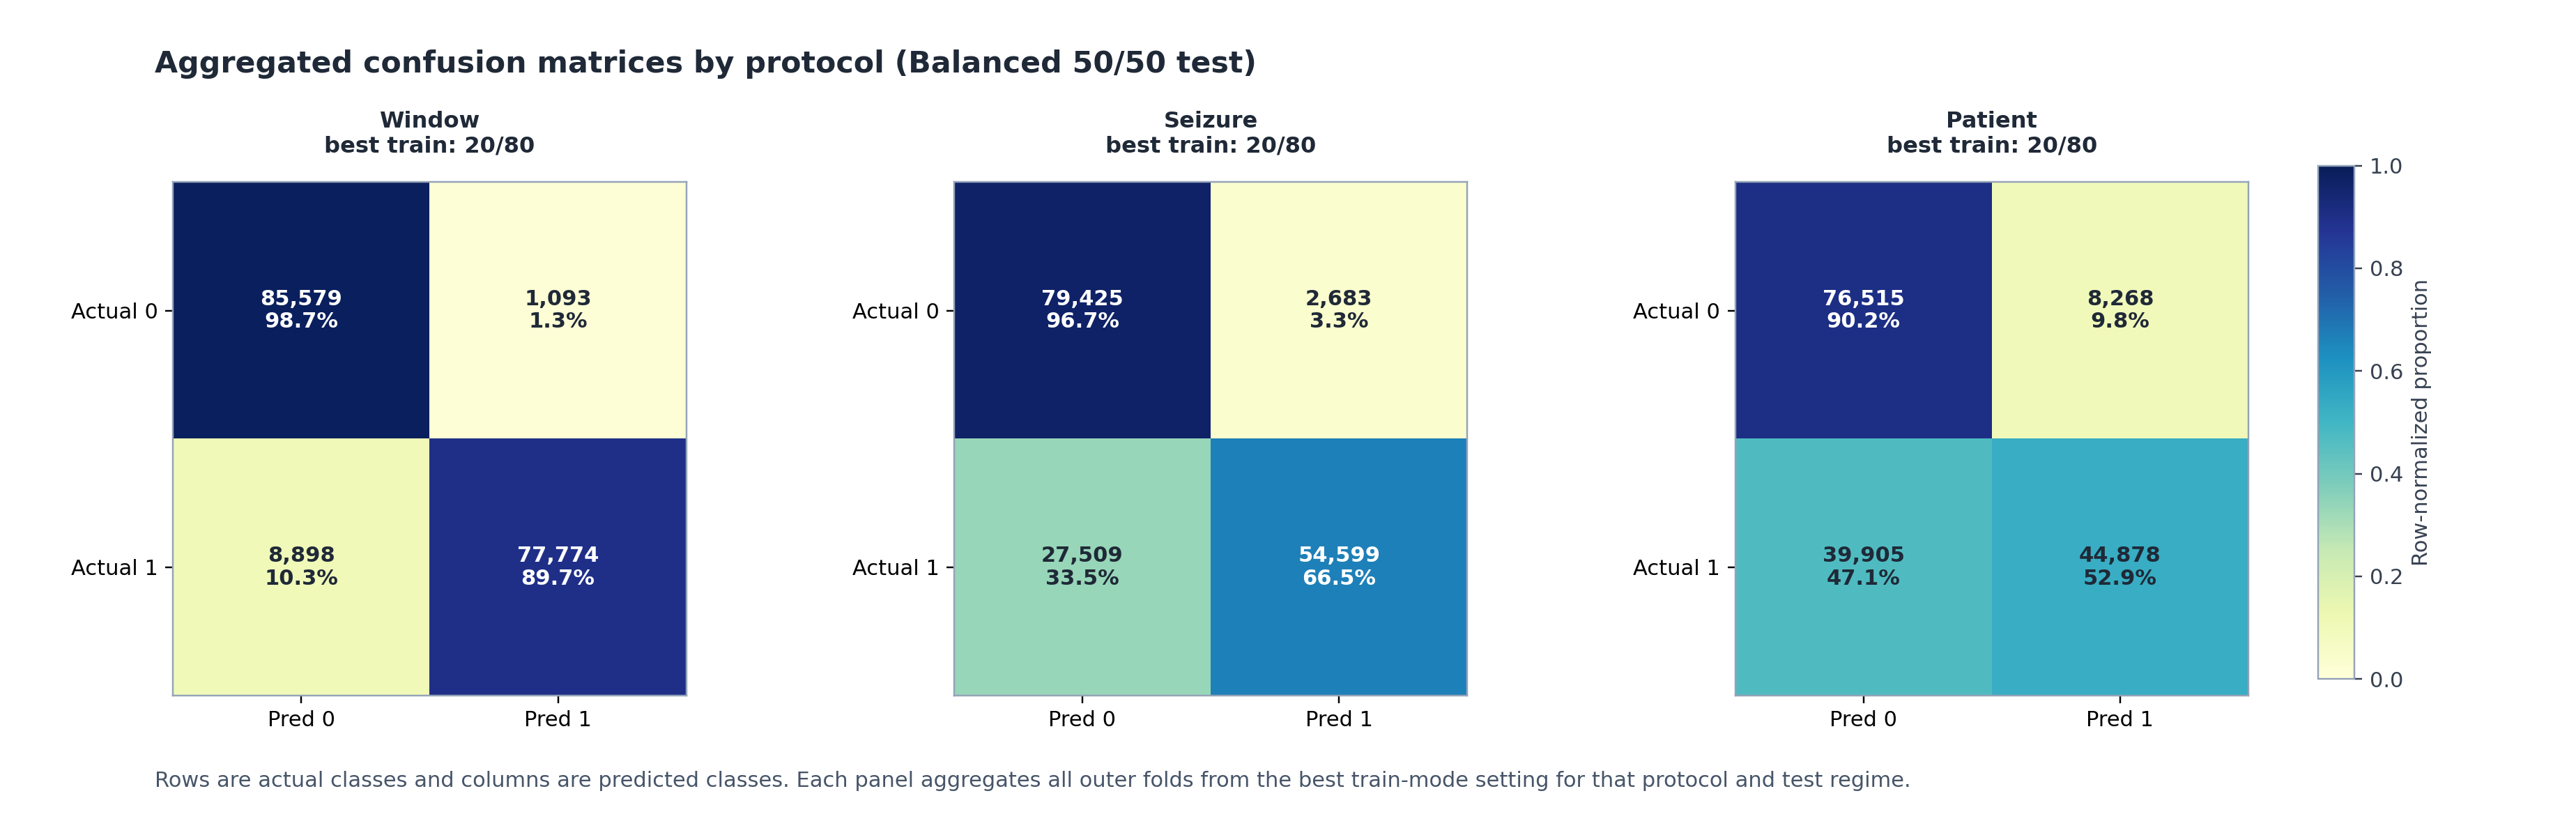

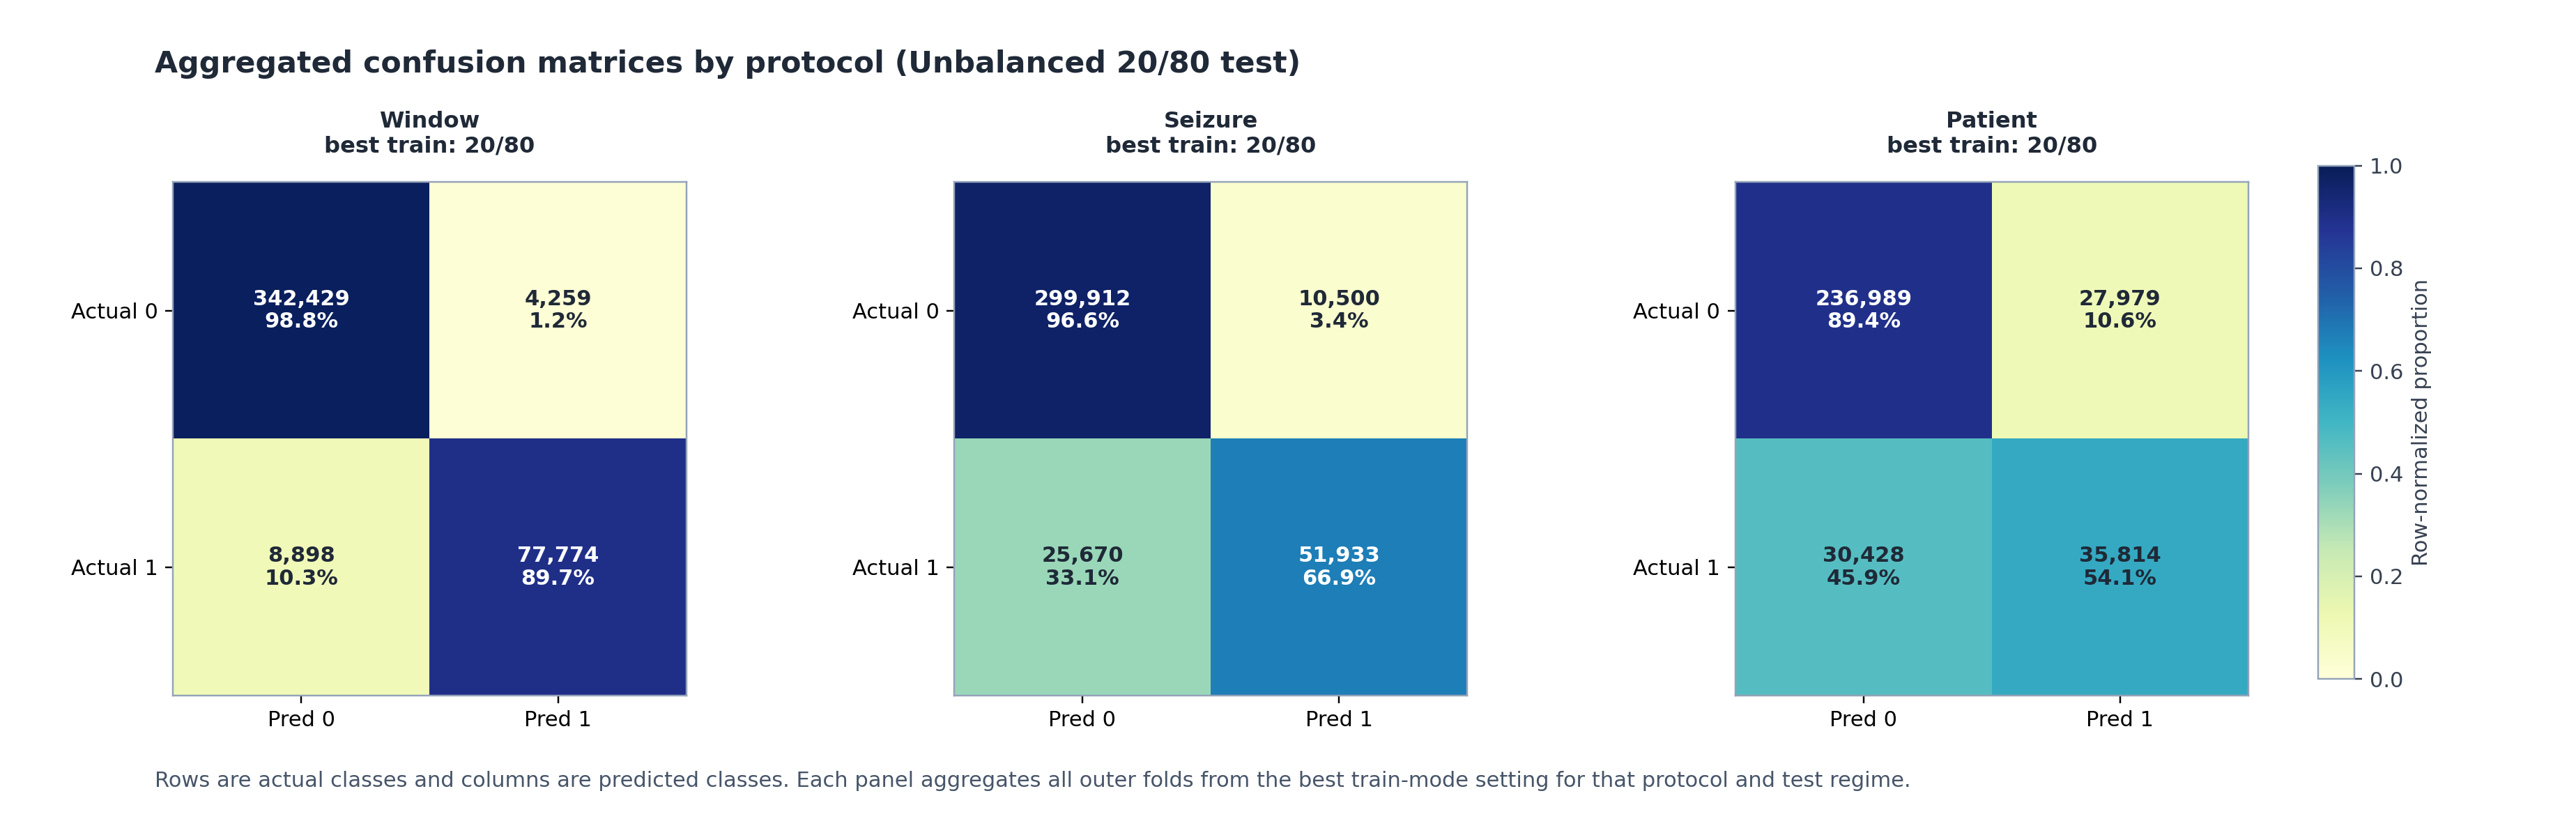

# Applications Discussion

## Protocol meanings

- `window`: optimistic upper bound because train/test share patient and event context.
- `seizure`: personalized unseen-event evaluation for known subjects.
- `patient`: population evaluation on unseen subjects.

## Balanced vs unbalanced

- Balanced test sets are easier to compare visually across folds.
- Unbalanced test sets better expose false positives and trustworthiness under realistic class ratios.

## Current summary

- `patient` with `balanced_50_50` train and `balanced_50_50` test: F1 `0.6420 ± 0.2841`, AUC `0.8537 ± 0.1813`.
- `patient` with `balanced_50_50` train and `unbalanced_20_80` test: F1 `0.5312 ± 0.2513`, AUC `0.8539 ± 0.1801`.
- `patient` with `unbalanced_20_80` train and `balanced_50_50` test: F1 `0.6611 ± 0.2931`, AUC `0.8536 ± 0.1867`.
- `patient` with `unbalanced_20_80` train and `unbalanced_20_80` test: F1 `0.5561 ± 0.2658`, AUC `0.8541 ± 0.1852`.
- `seizure` with `balanced_50_50` train and `balanced_50_50` test: F1 `0.6707 ± 0.2575`, AUC `0.9027 ± 0.1263`.
- `seizure` with `balanced_50_50` train and `unbalanced_20_80` test: F1 `0.6342 ± 0.2470`, AUC `0.9028 ± 0.1249`.
- `seizure` with `unbalanced_20_80` train and `balanced_50_50` test: F1 `0.6921 ± 0.2540`, AUC `0.9082 ± 0.1266`.
- `seizure` with `unbalanced_20_80` train and `unbalanced_20_80` test: F1 `0.6607 ± 0.2444`, AUC `0.9084 ± 0.1254`.
- `window` with `balanced_50_50` train and `balanced_50_50` test: F1 `0.9248 ± 0.0032`, AUC `0.9875 ± 0.0012`.
- `window` with `balanced_50_50` train and `unbalanced_20_80` test: F1 `0.8999 ± 0.0039`, AUC `0.9876 ± 0.0011`.
- `window` with `unbalanced_20_80` train and `balanced_50_50` test: F1 `0.9396 ± 0.0039`, AUC `0.9912 ± 0.0011`.
- `window` with `unbalanced_20_80` train and `unbalanced_20_80` test: F1 `0.9220 ± 0.0038`, AUC `0.9913 ± 0.0010`.


# Report-ready Notes

## Suggested narrative

- Start by framing window-level validation as the upper bound.
- Then compare seizure holdout as the personalized setting.
- Finish with patient holdout as the most realistic population-level setting.

## Top metric rows

- `window` / `unbalanced_20_80` / `balanced_50_50` achieved mean F1 `0.9396` and mean AUC `0.9912`.
- `window` / `balanced_50_50` / `balanced_50_50` achieved mean F1 `0.9248` and mean AUC `0.9875`.
- `window` / `unbalanced_20_80` / `unbalanced_20_80` achieved mean F1 `0.9220` and mean AUC `0.9913`.


In [21]:
show_preview(ROOT / 'fold7_results_and_reporting' / 'main_results.csv', n=20)
show_figure(ROOT / 'fold7_results_and_reporting' / 'summary_figures' / 'f1_by_protocol.png', 'f1_by_protocol', width=1100)
show_figure(ROOT / 'fold7_results_and_reporting' / 'summary_figures' / 'auc_by_protocol.png', 'auc_by_protocol', width=1100)
show_figure(ROOT / 'fold7_results_and_reporting' / 'summary_figures' / 'confusion_matrices_balanced.png', 'confusion_matrices_balanced', width=1300)
show_figure(ROOT / 'fold7_results_and_reporting' / 'summary_figures' / 'confusion_matrices_unbalanced.png', 'confusion_matrices_unbalanced', width=1300)
show_preview(ROOT / 'fold7_results_and_reporting' / 'applications_discussion.md')
show_preview(ROOT / 'fold7_results_and_reporting' / 'report_ready_notes.md')


### Fold 7 Static Tables

> Static fallback for the main result table and report text.

<div style="margin:14px 0 22px 0;padding:12px 14px;border:1px solid #e5e7eb;border-left:6px solid #4b5563;border-radius:10px;background:#fcfcfd;"><div style="font-weight:700;color:#1f2937;margin-bottom:6px;">Main results table</div><div style="color:#4b5563;margin-bottom:10px;">Showing full table: 12 rows x 17 columns.</div><div style="overflow-x:auto;"><table style="border-collapse:collapse;width:100%;font-size:13px;line-height:1.45;border:1px solid #d1d5db;background:white;"><thead><tr><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">protocol</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">train_mode</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">test_mode</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">n_folds</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">accuracy_mean</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">accuracy_std</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">precision_mean</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">precision_std</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">recall_mean</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">recall_std</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">specificity_mean</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">specificity_std</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">f1_mean</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">f1_std</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">roc_auc_mean</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">roc_auc_std</th><th style="border:1px solid #d1d5db;padding:6px 8px;background:#f8fafc;text-align:left;">n_rows_mean</th></tr></thead><tbody><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.7294223284116829</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.1474196623264196</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.819786024857699</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.1881230589010045</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.6311852204350261</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.3493745835152995</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.8276594363883395</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.2131747600918835</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.6420250514001993</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.2841327858229603</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.8536869907658299</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.1813001009833912</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7065.25</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.7896690334714108</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.1448387963222318</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.6242450478371866</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.2808328705888257</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.6307172417422668</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.3485761874644327</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.8294069814036967</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.2131250437446183</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.5311965962242492</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.2512718645036721</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.8539046994837198</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.1801349274937379</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">13800.416666666666</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.7444207636325643</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.1584324173571482</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.8326887565141897</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.1875915138473538</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.6487267116467121</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.3469875824189516</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.8401148156184163</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.2094543610673102</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.6611095267578245</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.2931446298994368</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.8536264278751201</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.1867445762538889</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">7065.25</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">patient</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">24</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.8026457978862286</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.1507387083762507</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.6459894828478261</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.2711846354966768</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.6487653980994071</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.3462803217210037</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.841115897832934</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.2097117536628216</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.5560968991073846</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.2657922696311693</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.8540717436907647</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.1851678520127914</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">13800.416666666666</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">181</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.7705417281028185</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.1322381446335119</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.906368108676502</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.1887673632785797</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.5749988441422188</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.2744936171243081</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.9660846120634182</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0483600640612677</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.6707453282492644</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.2574912618438027</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.9027442010234528</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.1262946950149975</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">907.270718232044</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">181</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.8875433578599692</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0571955995964704</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.7981951855194125</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.2313936684395703</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.5748712244511571</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.274739346930878</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.965711391212172</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0470132672410249</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.6342386589319686</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.2469651472199873</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.9028106780726068</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.1249270721800131</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2143.729281767956</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">181</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.7839805331511897</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.1313804368656182</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.9207767447498604</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.1679399350152282</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.5963768219240927</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.269727721248402</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.9715842443782868</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0391596664718889</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.6920934119044693</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.2539883281690109</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.9082045235229438</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.1266175746551715</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">907.270718232044</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">seizure</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">181</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.8967285067859635</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0546254390483191</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.8262267808008021</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.2154965374269564</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.5965782844399342</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.2700124104804294</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.9717660623724708</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0383341525193748</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.6607090434031523</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.2443891247318498</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.9084431958095938</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.1254416900780624</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">2143.729281767956</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.9288062755636024</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0027747792483527</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.9802571137234364</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.002450996323464</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.8752538209177055</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0064884453949304</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.9823587302094994</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0023144489513775</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.9247670973364628</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0032076835146044</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.987508974173054</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0012057299578826</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">11556.266666666666</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.9610531421053136</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0014880263804153</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.926009881923546</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0062649785650504</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.8752538209177055</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0064884453949304</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.9825029724022156</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.001657158008413</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.8998894979041642</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0038502972471541</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.9875828398403024</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0010569350263744</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">28890.666666666668</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">balanced_50_50</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.942363055119361</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0035420534902485</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.9861427380245466</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0018835549527129</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.8973368561922349</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0067189917483181</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.987389254046487</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0017254382964316</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.9396340662929498</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0038849332431138</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.9911900426104556</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0011069161253708</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">11556.266666666666</td></tr><tr><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">window</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">unbalanced_20_80</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">15</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.9696395340765144</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0014185076022319</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.9481126822024376</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0048467323871049</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.8973368561922349</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0067189917483181</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.987715203547584</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0012348474003206</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.9220049295808348</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0037593825910143</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.991286153136871</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">0.0009680226532967</td><td style="border:1px solid #d1d5db;padding:6px 8px;vertical-align:top;">28890.666666666668</td></tr></tbody></table></div></div>

<div style="margin:14px 0 22px 0;padding:12px 14px;border:1px solid #e5e7eb;border-left:6px solid #4b5563;border-radius:10px;background:#fcfcfd;"><div style="font-weight:700;color:#1f2937;margin-bottom:10px;">Applications discussion</div><pre style="margin:0;white-space:pre-wrap;word-break:break-word;font-size:13px;line-height:1.6;color:#374151;"># Applications Discussion

## Protocol meanings

- `window`: optimistic upper bound because train/test share patient and event context.
- `seizure`: personalized unseen-event evaluation for known subjects.
- `patient`: population evaluation on unseen subjects.

## Balanced vs unbalanced

- Balanced test sets are easier to compare visually across folds.
- Unbalanced test sets better expose false positives and trustworthiness under realistic class ratios.

## Current summary

- `patient` with `balanced_50_50` train and `balanced_50_50` test: F1 `0.6420 ± 0.2841`, AUC `0.8537 ± 0.1813`.
- `patient` with `balanced_50_50` train and `unbalanced_20_80` test: F1 `0.5312 ± 0.2513`, AUC `0.8539 ± 0.1801`.
- `patient` with `unbalanced_20_80` train and `balanced_50_50` test: F1 `0.6611 ± 0.2931`, AUC `0.8536 ± 0.1867`.
- `patient` with `unbalanced_20_80` train and `unbalanced_20_80` test: F1 `0.5561 ± 0.2658`, AUC `0.8541 ± 0.1852`.
- `seizure` with `balanced_50_50` train and `balanced_50_50` test: F1 `0.6707 ± 0.2575`, AUC `0.9027 ± 0.1263`.
- `seizure` with `balanced_50_50` train and `unbalanced_20_80` test: F1 `0.6342 ± 0.2470`, AUC `0.9028 ± 0.1249`.
- `seizure` with `unbalanced_20_80` train and `balanced_50_50` test: F1 `0.6921 ± 0.2540`, AUC `0.9082 ± 0.1266`.
- `seizure` with `unbalanced_20_80` train and `unbalanced_20_80` test: F1 `0.6607 ± 0.2444`, AUC `0.9084 ± 0.1254`.
- `window` with `balanced_50_50` train and `balanced_50_50` test: F1 `0.9248 ± 0.0032`, AUC `0.9875 ± 0.0012`.
- `window` with `balanced_50_50` train and `unbalanced_20_80` test: F1 `0.8999 ± 0.0039`, AUC `0.9876 ± 0.0011`.
- `window` with `unbalanced_20_80` train and `balanced_50_50` test: F1 `0.9396 ± 0.0039`, AUC `0.9912 ± 0.0011`.
- `window` with `unbalanced_20_80` train and `unbalanced_20_80` test: F1 `0.9220 ± 0.0038`, AUC `0.9913 ± 0.0010`.</pre></div>

<div style="margin:14px 0 22px 0;padding:12px 14px;border:1px solid #e5e7eb;border-left:6px solid #4b5563;border-radius:10px;background:#fcfcfd;"><div style="font-weight:700;color:#1f2937;margin-bottom:10px;">Report-ready notes</div><pre style="margin:0;white-space:pre-wrap;word-break:break-word;font-size:13px;line-height:1.6;color:#374151;"># Report-ready Notes

## Suggested narrative

- Start by framing window-level validation as the upper bound.
- Then compare seizure holdout as the personalized setting.
- Finish with patient holdout as the most realistic population-level setting.

## Top metric rows

- `window` / `unbalanced_20_80` / `balanced_50_50` achieved mean F1 `0.9396` and mean AUC `0.9912`.
- `window` / `balanced_50_50` / `balanced_50_50` achieved mean F1 `0.9248` and mean AUC `0.9875`.
- `window` / `unbalanced_20_80` / `unbalanced_20_80` achieved mean F1 `0.9220` and mean AUC `0.9913`.</pre></div>



### Embedded Confusion Matrix Gallery

> Static inline confusion-matrix figures for quick viewing. These render directly when the notebook is opened, even before rerunning Fold 7.

<div style="margin: 22px 0 28px 0;">
  <div style="font-weight: 700; margin-bottom: 8px; font-size: 18px; color: #1f2937;">图 12. Balanced test 条件下按 protocol 聚合的混淆矩阵</div>
  <img src="fold7_results_and_reporting/summary_figures/confusion_matrices_balanced.png" style="width: 100%; max-width: 1300px; border: 1px solid #ddd; border-radius: 8px; display: block;" />
  <div style="margin-top: 10px; padding: 12px 14px; border: 1px solid #ddd4c5; border-left: 6px solid #8c5a3c; border-radius: 10px; background: #fffdf8; line-height: 1.68; color: #374151;">
    <div style="font-weight: 700; color: #1f2937; margin-bottom: 6px;">中文描述与分析</div>
    <div>描述：该图在 balanced 50/50 测试条件下，对每个 protocol 选择其最佳 train setting，并将全部 outer folds 的混淆矩阵聚合后展示。每个格子同时给出总计数与按行归一化比例。分析：window 的对角项最强，说明在共享病人与事件上下文时模型最容易达到高召回与高特异性；seizure 次之，patient 最难，主要表现为正类召回下降。这与 challenge 中 window &gt; seizure &gt; patient 的泛化难度排序一致。</div>
    <div style="font-weight: 700; color: #1f2937; margin: 12px 0 6px 0;">English Description and Analysis</div>
    <div>Description: Under balanced 50/50 testing, this figure selects the best train setting for each protocol and aggregates the confusion matrices across all outer folds. Each cell reports both the total count and the row-normalized proportion. Analysis: Window holdout has the strongest diagonal, seizure holdout is intermediate, and patient holdout is hardest, with the main drop coming from positive-class recall. This matches the intended challenge hierarchy of window &gt; seizure &gt; patient.</div>
  </div>
</div>

<div style="margin: 22px 0 28px 0;">
  <div style="font-weight: 700; margin-bottom: 8px; font-size: 18px; color: #1f2937;">图 13. Unbalanced test 条件下按 protocol 聚合的混淆矩阵</div>
  <img src="fold7_results_and_reporting/summary_figures/confusion_matrices_unbalanced.png" style="width: 100%; max-width: 1300px; border: 1px solid #ddd; border-radius: 8px; display: block;" />
  <div style="margin-top: 10px; padding: 12px 14px; border: 1px solid #ddd4c5; border-left: 6px solid #8c5a3c; border-radius: 10px; background: #fffdf8; line-height: 1.68; color: #374151;">
    <div style="font-weight: 700; color: #1f2937; margin-bottom: 6px;">中文描述与分析</div>
    <div>描述：该图在 unbalanced 20/80 测试条件下，以同样方式汇总三种 protocol 的聚合混淆矩阵。分析：在更接近真实类分布的测试中，负类样本占主导，因此高特异性更容易体现在大量 true negatives 上；但正类召回与 false positives 的权衡也更关键。对于 seizure 和 patient protocol，这张图比 balanced 测试更能反映部署场景下的误报风险与可信度。</div>
    <div style="font-weight: 700; color: #1f2937; margin: 12px 0 6px 0;">English Description and Analysis</div>
    <div>Description: This figure summarizes the same protocol-wise aggregate confusion matrices under unbalanced 20/80 testing. Analysis: Because the negative class dominates, high specificity becomes visually tied to a large true-negative block, while the recall-versus-false-positive trade-off becomes more deployment-relevant. For seizure and patient holdout especially, this view better exposes trustworthiness under realistic class ratios.</div>
  </div>
</div>


## Fold 8: Future Model Slot

**Goal**
- Reserve a clean extension point for a second model without changing the data split or evaluation contracts.

**Human Takeaway**
- V1 stays disciplined: one CNN baseline, one experiment matrix, one reporting pipeline.

In [22]:
show_preview(ROOT / 'fold8_future_slot' / 'model_io_contract.md')
show_preview(ROOT / 'fold8_future_slot' / 'future_model_readme.md')

# Model IO Contract

- Future models must reuse the existing `master_index.parquet` and split artifacts from `fold3_split_protocols`.
- Future training runs must preserve the directory convention:
  - `fold5_cnn_training/<protocol>/<train_mode>/outer_fold_XXX/`
  - `fold6_evaluation/<protocol>/<train_mode>/outer_fold_XXX/<test_mode>/`
- Future models must emit the same public artifact names:
  - `best.pt`
  - `train_log.csv`
  - `learning_curve.png`
  - `predictions.parquet`
  - `metrics.json`
  - `confusion_matrix.csv`
  - `roc_curve.csv`
  - `pr_curve.csv`
- Prediction files must keep the same schema:
  - `row_id, protocol, outer_fold_id, train_mode, test_mode, y_true, y_score, y_pred, threshold, checkpoint_path`
- Metrics files must keep the same keys:
  - `accuracy, precision, recall, specificity, f1, roc_auc, tn, fp, fn, tp, n_rows`



# Future Model Slot

This directory is the reserved landing zone for the second model family.

## Not in scope for V1

- LSTM temporal model
- Spiking transformer variant
- Classic SVM baseline

## What to reuse later

- `helpers/data_io.py`
- `helpers/splits.py`
- `helpers/eval.py`
- The report notebook `main_pipeline.ipynb`
- The tmux launch pattern in `scripts/launch_tmux_matrix.sh`

## Expected next step

Add a second training helper or model head while preserving the existing split and evaluation contracts.



### Fold 8 Static Text

> Static fallback for the future-slot documentation.

<div style="margin:14px 0 22px 0;padding:12px 14px;border:1px solid #e5e7eb;border-left:6px solid #4b5563;border-radius:10px;background:#fcfcfd;"><div style="font-weight:700;color:#1f2937;margin-bottom:10px;">Model IO contract</div><pre style="margin:0;white-space:pre-wrap;word-break:break-word;font-size:13px;line-height:1.6;color:#374151;"># Model IO Contract

- Future models must reuse the existing `master_index.parquet` and split artifacts from `fold3_split_protocols`.
- Future training runs must preserve the directory convention:
  - `fold5_cnn_training/&lt;protocol&gt;/&lt;train_mode&gt;/outer_fold_XXX/`
  - `fold6_evaluation/&lt;protocol&gt;/&lt;train_mode&gt;/outer_fold_XXX/&lt;test_mode&gt;/`
- Future models must emit the same public artifact names:
  - `best.pt`
  - `train_log.csv`
  - `learning_curve.png`
  - `predictions.parquet`
  - `metrics.json`
  - `confusion_matrix.csv`
  - `roc_curve.csv`
  - `pr_curve.csv`
- Prediction files must keep the same schema:
  - `row_id, protocol, outer_fold_id, train_mode, test_mode, y_true, y_score, y_pred, threshold, checkpoint_path`
- Metrics files must keep the same keys:
  - `accuracy, precision, recall, specificity, f1, roc_auc, tn, fp, fn, tp, n_rows`</pre></div>

<div style="margin:14px 0 22px 0;padding:12px 14px;border:1px solid #e5e7eb;border-left:6px solid #4b5563;border-radius:10px;background:#fcfcfd;"><div style="font-weight:700;color:#1f2937;margin-bottom:10px;">Future model readme</div><pre style="margin:0;white-space:pre-wrap;word-break:break-word;font-size:13px;line-height:1.6;color:#374151;"># Future Model Slot

This directory is the reserved landing zone for the second model family.

## Not in scope for V1

- LSTM temporal model
- Spiking transformer variant
- Classic SVM baseline

## What to reuse later

- `helpers/data_io.py`
- `helpers/splits.py`
- `helpers/eval.py`
- The report notebook `main_pipeline.ipynb`
- The tmux launch pattern in `scripts/launch_tmux_matrix.sh`

## Expected next step

Add a second training helper or model head while preserving the existing split and evaluation contracts.</pre></div>

